# Biblioteka Matplotlib - Część 3

## Elementy składowe wykresu i stylowanie

W tej części nauczysz się jak profesjonalnie dostosowywać wygląd wykresów.

## Setup - Import bibliotek i danych

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline

# Wczytaj dane
df_pogoda = pd.read_csv('../data/pogoda.csv')
df_pogoda['data'] = pd.to_datetime(df_pogoda['data'])
df_sprzedaz = pd.read_csv('../data/sprzedaz.csv')
df_sprzedaz['data'] = pd.to_datetime(df_sprzedaz['data'])
df_sprzedaz['wartosc_sprzedazy'] = df_sprzedaz['kwota'] * df_sprzedaz['ilosc']

print("Dane wczytane pomyślnie!")

Dane wczytane pomyślnie!


## 1. Elementy składowe wykresu

Każdy wykres składa się z wielu elementów. Poznajmy je wszystkie!

### 1.1 Tytuł (`set_title`, `suptitle`)

Tytuł to najważniejszy element - mówi, co wykres przedstawia.

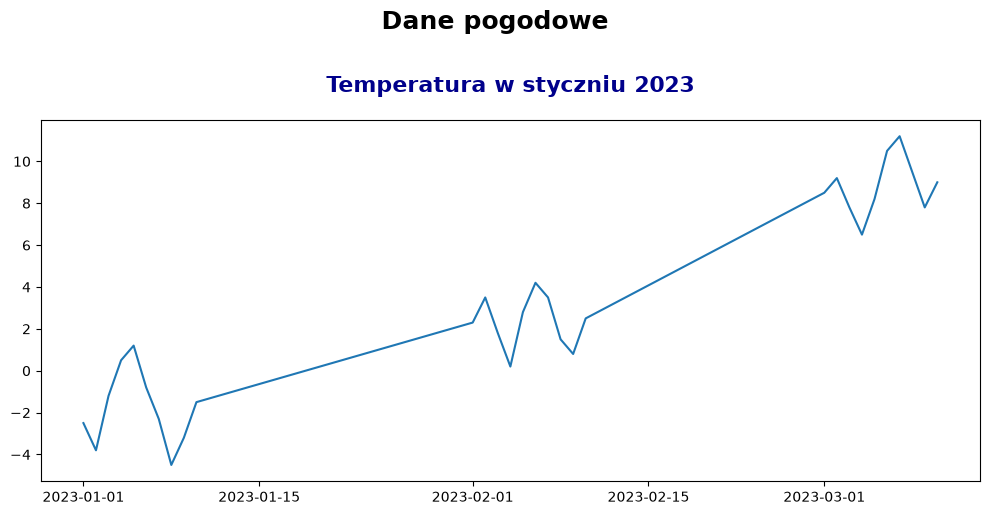

In [7]:
# Przykład z tytułami
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_pogoda['data'].head(30), df_pogoda['temperatura'].head(30))

# Tytuł wykresu
ax.set_title('Temperatura w styczniu 2023', 
             fontsize=16,           # Rozmiar czcionki
             fontweight='bold',     # Pogrubienie
             color='darkblue',      # Kolor
             pad=20)                # Odstęp od wykresu

# Tytuł całej figury (jeśli masz wiele subplotów)
fig.suptitle('Dane pogodowe', fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

**Parametry pozycjonowania tytułów:**

**`suptitle` (tytuł całej figury):**
- `y` - pozycja w pionie (0.0 = dół figury, 1.0 = góra figury)
  - Wartości > 1.0 = tytuł PONAD wykresem (np. `y=1.02`)
  - Wartości < 1.0 = tytuł NA wykresie (może nakładać się na dane)
  - Domyślnie: `y=0.98` (tuż pod górną krawędzią)
- `x` - pozycja w poziomie (0.0 = lewa krawędź, 0.5 = środek, 1.0 = prawa krawędź)
  - Domyślnie: `x=0.5` (wyśrodkowany)
  - Przykład: `fig.suptitle('Tytuł', x=0.2, y=1.05)` → lewy górny róg, powyżej wykresu

**`set_title` (tytuł pojedynczego wykresu):**
- `pad` - odstęp od wykresu w punktach (1 punkt ≈ 1/72 cala)
  - Przykład: `pad=20` = większy odstęp
  - Domyślnie: `pad=6`
- **NIE MA** parametrów `x` i `y` (pozycja ustalona automatycznie nad osią)
- Można użyć `loc` dla wyrównania: `loc='left'`, `loc='center'`, `loc='right'`

**Kiedy używać `y` w `suptitle`?**
- `y=1.02` gdy masz `tight_layout()` (tytuł nie nachodzi na wykresy)
- `y=0.98` dla większej kontroli bez `tight_layout()`
- `y=1.05` dla dodatkowej przestrzeni nad wykresem

### 1.2 Opisy osi (`set_xlabel`, `set_ylabel`)

**KAŻDA oś MUSI mieć opis z jednostką!**

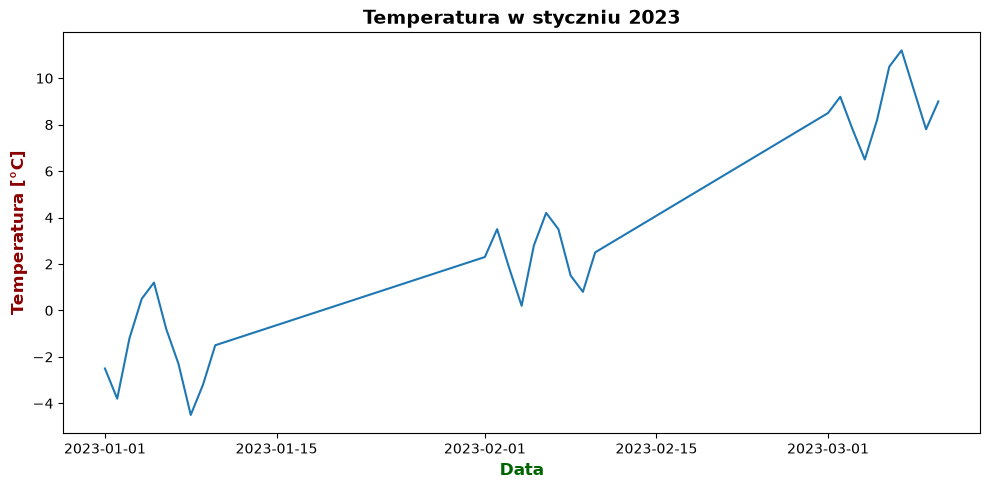

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_pogoda['data'].head(30), df_pogoda['temperatura'].head(30))

ax.set_title('Temperatura w styczniu 2023', fontsize=14, fontweight='bold')

# Opisy osi
ax.set_xlabel('Data',                    # Tekst
              fontsize=12,               # Rozmiar
              fontweight='bold',         # Pogrubienie
              color='darkgreen')         # Kolor

ax.set_ylabel('Temperatura [°C]',        # Tekst Z JEDNOSTKĄ!
              fontsize=12,
              fontweight='bold',
              color='darkred')

plt.tight_layout()
plt.show()

### 1.3 Legenda (`legend`)

Legenda wyjaśnia, co oznaczają różne linie/serie na wykresie.

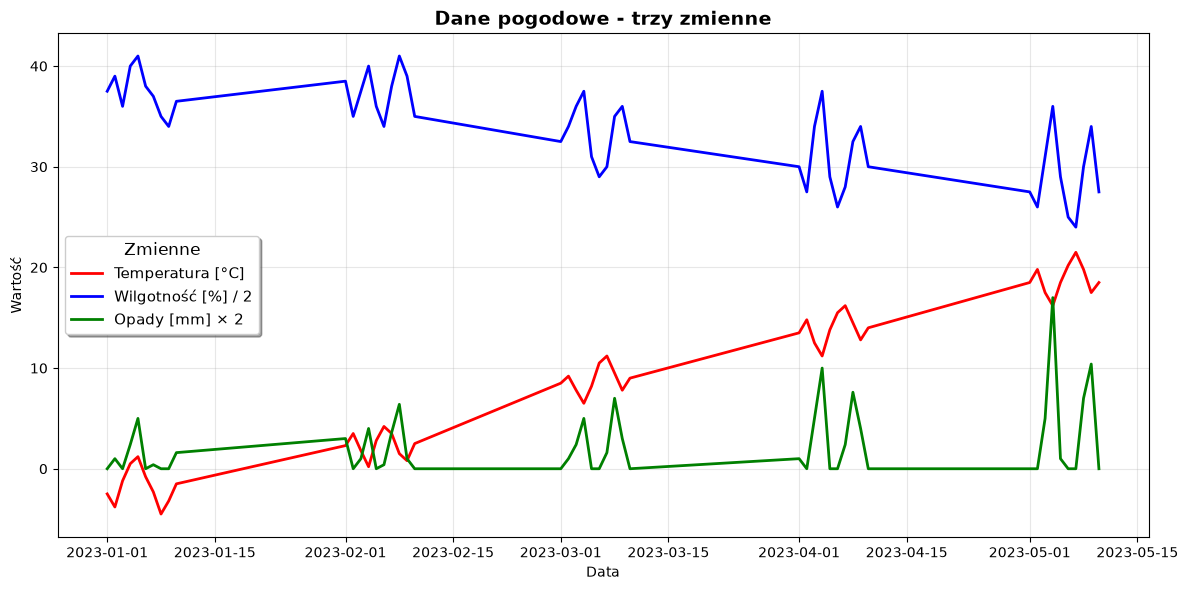

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

# Trzy linie
dane = df_pogoda.head(50)
ax.plot(dane['data'], dane['temperatura'], label='Temperatura [°C]', color='red', linewidth=2)
ax.plot(dane['data'], dane['wilgotnosc']/2, label='Wilgotność [%] / 2', color='blue', linewidth=2)
ax.plot(dane['data'], dane['opady']*2, label='Opady [mm] × 2', color='green', linewidth=2)

# Legenda
ax.legend(loc='best',                    # Automatyczne położenie
          fontsize=11,                   # Rozmiar czcionki
          frameon=True,                  # Ramka
          shadow=True,                   # Cień
          fancybox=True,                 # Zaokrąglone rogi
          title='Zmienne',               # Tytuł legendy
          title_fontsize=12,
         )             # Rozmiar tytułu

ax.set_title('Dane pogodowe - trzy zmienne', fontsize=14, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Wartość')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Pozycje legendy:**
- `'best'` - automatycznie najlepsze miejsce
- `'upper left'`, `'upper right'`, `'lower left'`, `'lower right'`
- `'center'`, `'center left'`, `'center right'`
- `'upper center'`, `'lower center'`
- Można też użyć współrzędnych: `bbox_to_anchor=(1.05, 1)` - poza wykresem

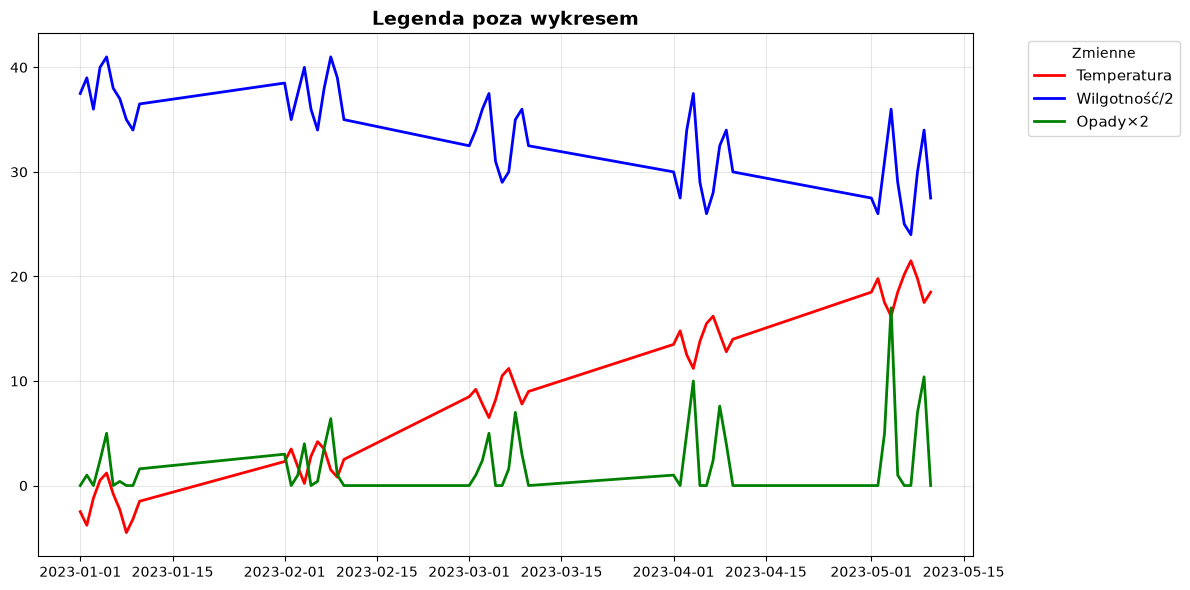

In [12]:
# Legenda poza wykresem
fig, ax = plt.subplots(figsize=(12, 6))

dane = df_pogoda.head(50)
ax.plot(dane['data'], dane['temperatura'], label='Temperatura', color='red', linewidth=2)
ax.plot(dane['data'], dane['wilgotnosc']/2, label='Wilgotność/2', color='blue', linewidth=2)
ax.plot(dane['data'], dane['opady']*2, label='Opady×2', color='green', linewidth=2)

# Legenda na prawo od wykresu
ax.legend(bbox_to_anchor=(1.05, 1),      # Pozycja poza wykresem
          loc='upper left',               # Punkt zakotwiczenia
          fontsize=11,
          title='Zmienne')

ax.set_title('Legenda poza wykresem', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.4 Siatka (`grid`)

Siatka ułatwia odczytywanie wartości z wykresu.

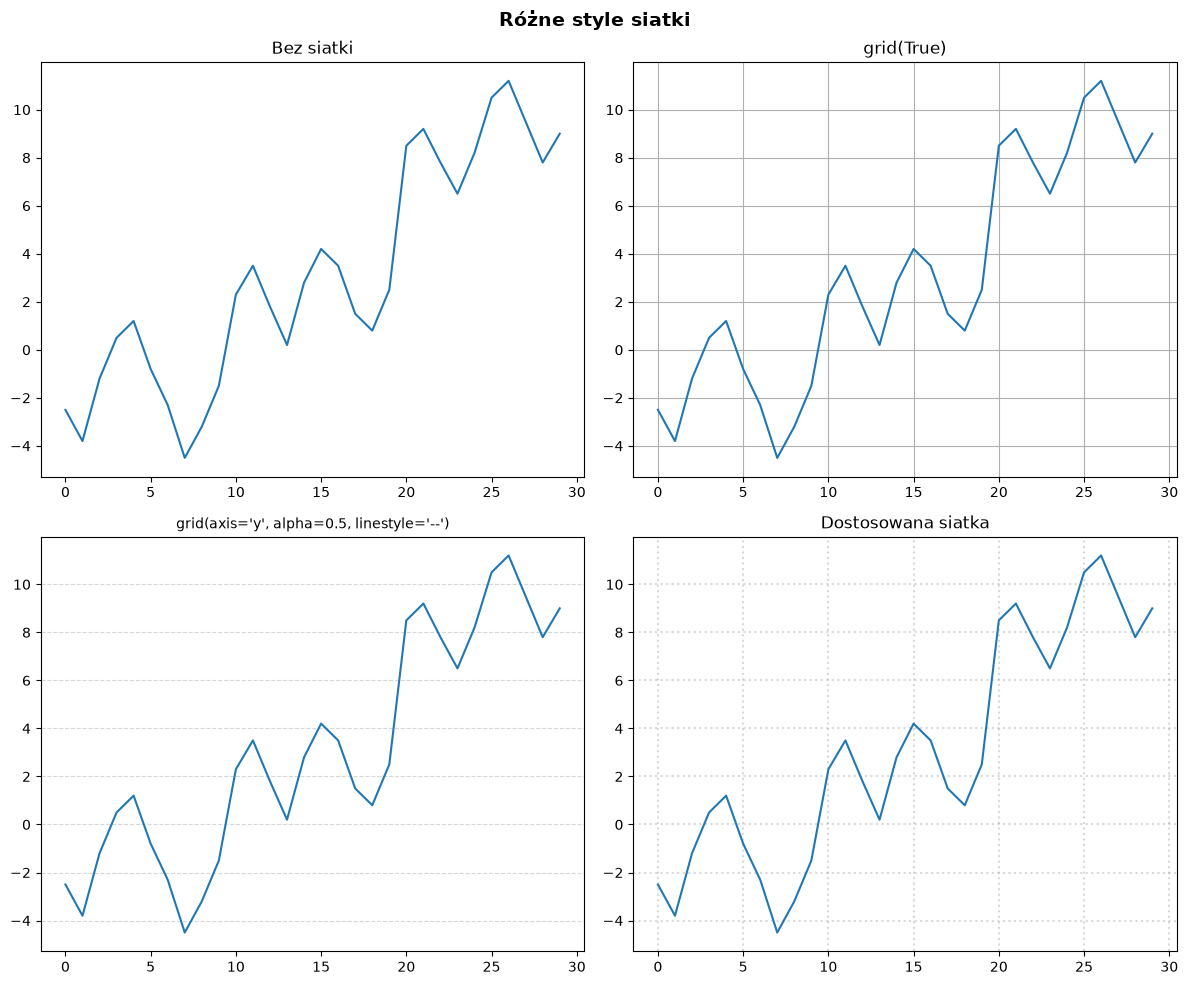

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

dane = df_pogoda['temperatura'].head(30)
x = range(len(dane))

# Bez siatki
axes[0].plot(x, dane)
axes[0].set_title('Bez siatki', fontsize=12)

# Siatka domyślna
axes[1].plot(x, dane)
axes[1].grid(True)
axes[1].set_title('grid(True)', fontsize=12)

# Tylko pozioma siatka
axes[2].plot(x, dane)
axes[2].grid(axis='y', alpha=0.5, linestyle='--')
axes[2].set_title("grid(axis='y', alpha=0.5, linestyle='--')", fontsize=10)

# Siatka z dostosowaniem
axes[3].plot(x, dane)
axes[3].grid(True, alpha=0.3, linestyle=':', linewidth=1.5, color='gray')
axes[3].set_title('Dostosowana siatka', fontsize=12)

plt.suptitle('Różne style siatki', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

### 1.5 Major/minor ticks i zaawansowany grid

Wcześniej poznaliśmy podstawową siatkę (`grid(True)`). Teraz zobaczmy jak stworzyć **profesjonalną siatkę** z **major i minor ticks** - jak na wykresach naukowych i technicznych!

#### Historia z wykresu inżynierskiego

Kolega inżynier poprosił Cię o pomoc:

> "Potrzebuję wykresu pomiarów z **dwiema podziałkami**: główną co 10 jednostek i pomocniczą co 2. **Siatka też powinna być dwupoziomowa** - ciemniejsza dla głównych linii, jaśniejsza dla pomocniczych. Tak jak w profesjonalnych wykresach technicznych!"

To wymaga użycia **major i minor ticks** + **zaawansowanego grid**!

---

#### Co to są major i minor ticks?

**Major ticks (główne):**
- Duże podziałki na osi (np. co 10, 20, 50)
- Mają etykiety z wartościami
- Grubsze linie siatki

**Minor ticks (pomocnicze):**
- Małe podziałki między major ticks (np. co 1, 2, 5)
- Zazwyczaj bez etykiet
- Cieńsze, subtelne linie siatki

**Po co minor ticks?**
- Ułatwiają dokładny odczyt wartości
- Wyglądają profesjonalnie (jak wykresy naukowe, techniczne)
- Pokazują szczegółowość danych

---

#### Przykład 1: Ustawienie major i minor ticks

Użyjmy `ax.set_xticks()` i `ax.set_yticks()` z parametrem `minor=True` dla pomocniczych podziałek.

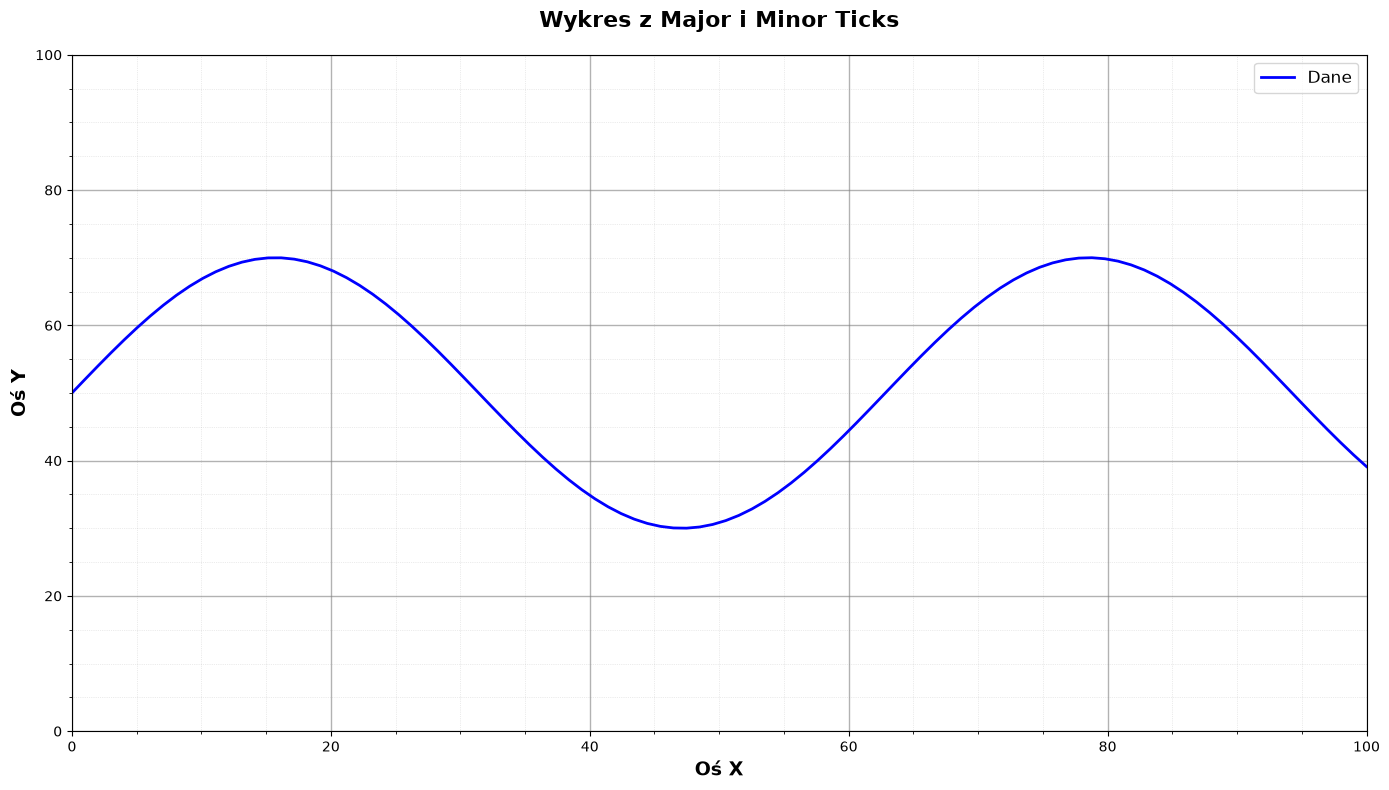

📊 Co zrobiliśmy?
   1. Major ticks (grube linie): co 20 jednostek (0, 20, 40, 60, 80, 100)
   2. Minor ticks (cienkie linie): co 5 jednostek (0, 5, 10, 15, 20...)
   3. Grid dla major: ciemniejszy (alpha=0.6), linia ciągła (-)
   4. Grid dla minor: jaśniejszy (alpha=0.3), linia kropkowana (:)

💡 Kluczowy parametr: minor=True w set_xticks() i set_yticks()!


In [15]:
import numpy as np

fig, ax = plt.subplots(figsize=(14, 8))

# Dane
x = np.linspace(0, 100, 100)
y = np.sin(x / 10) * 20 + 50

ax.plot(x, y, 'b-', linewidth=2, label='Dane')

# KROK 1: Ustaw MAJOR ticks (główne podziałki)
major_ticks_x = np.arange(0, 101, 20)  # Co 20 jednostek: 0, 20, 40, 60, 80, 100
major_ticks_y = np.arange(0, 101, 20)

ax.set_xticks(major_ticks_x)           # Ustaw major ticks na osi X
ax.set_yticks(major_ticks_y)           # Ustaw major ticks na osi Y

# KROK 2: Ustaw MINOR ticks (pomocnicze podziałki)
minor_ticks_x = np.arange(0, 101, 5)   # Co 5 jednostek: 0, 5, 10, 15, 20...
minor_ticks_y = np.arange(0, 101, 5)

ax.set_xticks(minor_ticks_x, minor=True)  # minor=True to KLUCZOWY parametr!
ax.set_yticks(minor_ticks_y, minor=True)

# KROK 3: Dodaj siatkę dla obu typów ticks
ax.grid(which='major', color='gray', linestyle='-', linewidth=1.0, alpha=0.6)  # Major grid
ax.grid(which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.3)  # Minor grid

# Stylizacja
ax.set_xlabel('Oś X', fontsize=14, fontweight='bold')
ax.set_ylabel('Oś Y', fontsize=14, fontweight='bold')
ax.set_title('Wykres z Major i Minor Ticks', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("📊 Co zrobiliśmy?")
print("   1. Major ticks (grube linie): co 20 jednostek (0, 20, 40, 60, 80, 100)")
print("   2. Minor ticks (cienkie linie): co 5 jednostek (0, 5, 10, 15, 20...)")
print("   3. Grid dla major: ciemniejszy (alpha=0.6), linia ciągła (-)")
print("   4. Grid dla minor: jaśniejszy (alpha=0.3), linia kropkowana (:)")
print("\n💡 Kluczowy parametr: minor=True w set_xticks() i set_yticks()!")

#### Przykład 2: Różne style grid dla major i minor

Parametr `which=` w `ax.grid()` kontroluje, **która siatka** jest rysowana:
- `which='major'` - tylko główne linie siatki
- `which='minor'` - tylko pomocnicze linie
- `which='both'` - obie (ale z tymi samymi ustawieniami)

**Best practice:** Wywołaj `ax.grid()` **dwa razy** - raz dla major, raz dla minor, z różnymi stylami!

Porównajmy różne konfiguracje:

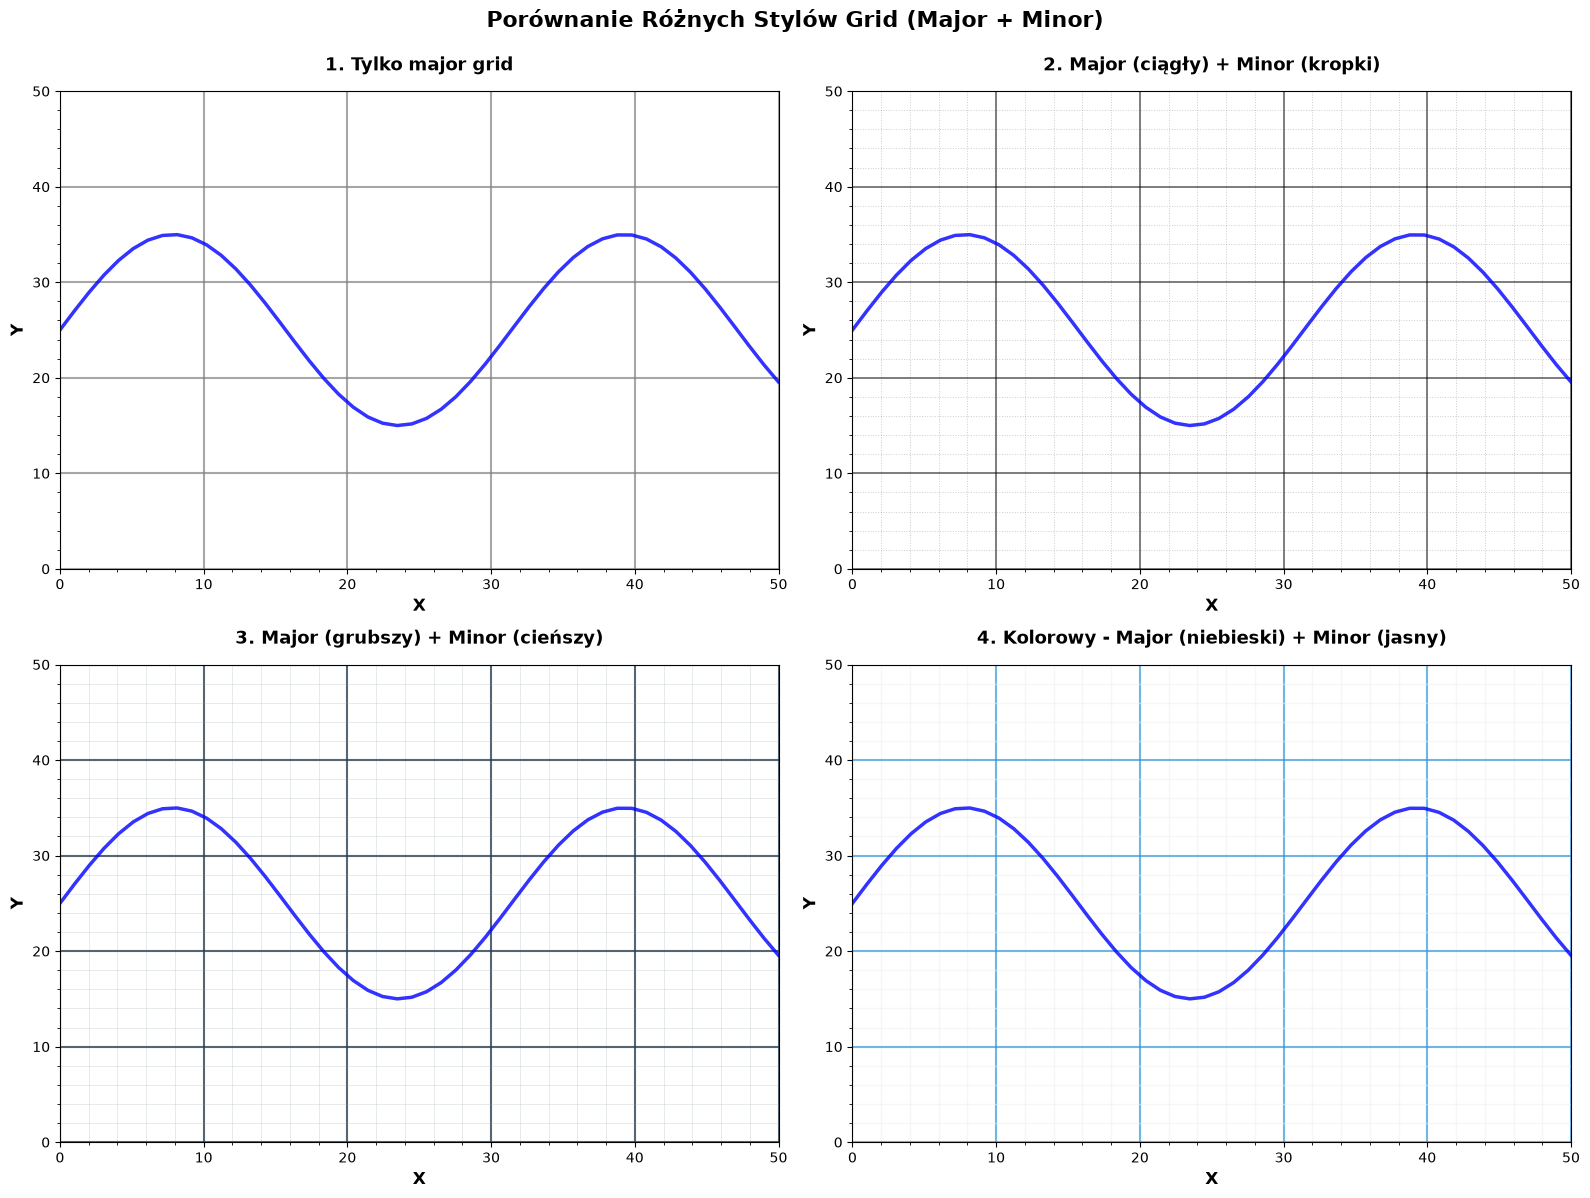

🎨 Popularne kombinacje stylów:
   1. Tylko major: Prosty, czytelny (dla prostych wykresów)
   2. Major ciągły + Minor kropkowany: Klasyczny styl (najczęściej używany) ✅
   3. Major grubszy + Minor cieńszy: Wyraźna hierarchia
   4. Kolorowy: Ładny, ale może odwracać uwagę od danych

💡 Rekomendacja: #2 (major ciągły, minor kropkowany) - uniwersalny i profesjonalny!


In [16]:
# Porównanie różnych stylów grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

# Dane bazowe
x = np.linspace(0, 50, 50)
y = np.sin(x / 5) * 10 + 25

# Różne konfiguracje grid
configs = [
    {
        'title': '1. Tylko major grid',
        'major': {'which': 'major', 'color': 'gray', 'linestyle': '-', 'linewidth': 1.5, 'alpha': 0.7},
        'minor': None  # Brak minor grid
    },
    {
        'title': '2. Major (ciągły) + Minor (kropki)',
        'major': {'which': 'major', 'color': 'black', 'linestyle': '-', 'linewidth': 1.2, 'alpha': 0.6},
        'minor': {'which': 'minor', 'color': 'gray', 'linestyle': ':', 'linewidth': 0.7, 'alpha': 0.4}
    },
    {
        'title': '3. Major (grubszy) + Minor (cieńszy)',
        'major': {'which': 'major', 'color': '#2c3e50', 'linestyle': '-', 'linewidth': 1.5, 'alpha': 0.8},
        'minor': {'which': 'minor', 'color': '#95a5a6', 'linestyle': '-', 'linewidth': 0.5, 'alpha': 0.3}
    },
    {
        'title': '4. Kolorowy - Major (niebieski) + Minor (jasny)',
        'major': {'which': 'major', 'color': '#3498db', 'linestyle': '-', 'linewidth': 1.5, 'alpha': 0.7},
        'minor': {'which': 'minor', 'color': '#ecf0f1', 'linestyle': '-', 'linewidth': 1.0, 'alpha': 0.5}
    }
]

for i, (ax, config) in enumerate(zip(axes, configs)):
    # Wykres bazowy
    ax.plot(x, y, 'b-', linewidth=2.5, alpha=0.8)
    
    # Ustaw major i minor ticks
    ax.set_xticks(np.arange(0, 51, 10))           # Major co 10
    ax.set_xticks(np.arange(0, 51, 2), minor=True)  # Minor co 2
    ax.set_yticks(np.arange(0, 51, 10))
    ax.set_yticks(np.arange(0, 51, 2), minor=True)
    
    # Zastosuj grid według konfiguracji
    if config['major']:
        ax.grid(**config['major'])
    
    if config['minor']:
        ax.grid(**config['minor'])
    
    # Stylizacja
    ax.set_xlabel('X', fontsize=12, fontweight='bold')
    ax.set_ylabel('Y', fontsize=12, fontweight='bold')
    ax.set_title(config['title'], fontsize=13, fontweight='bold', pad=15)
    ax.set_xlim(0, 50)
    ax.set_ylim(0, 50)

plt.suptitle('Porównanie Różnych Stylów Grid (Major + Minor)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("🎨 Popularne kombinacje stylów:")
print("   1. Tylko major: Prosty, czytelny (dla prostych wykresów)")
print("   2. Major ciągły + Minor kropkowany: Klasyczny styl (najczęściej używany) ✅")
print("   3. Major grubszy + Minor cieńszy: Wyraźna hierarchia")
print("   4. Kolorowy: Ładny, ale może odwracać uwagę od danych")
print("\n💡 Rekomendacja: #2 (major ciągły, minor kropkowany) - uniwersalny i profesjonalny!")

**Kluczowe spostrzeżenia - Major/Minor Ticks i Grid:**

✅ **Kiedy używać major/minor ticks:**
- Wykresy naukowe i techniczne (precyzyjny odczyt wartości)
- Duże zakresy danych (np. 0-100, 0-1000)
- Gdy chcesz profesjonalny, szczegółowy wygląd
- Wykresy do publikacji

📊 **Kompletny szablon:**
```python
import numpy as np

# Krok 1: Zdefiniuj pozycje ticks
major_ticks = np.arange(0, 101, 20)  # Główne: co 20
minor_ticks = np.arange(0, 101, 5)   # Pomocnicze: co 5

# Krok 2: Ustaw ticks na osiach
ax.set_xticks(major_ticks)           # Major ticks na X
ax.set_xticks(minor_ticks, minor=True)  # Minor ticks na X (minor=True!)
ax.set_yticks(major_ticks)           # Major ticks na Y
ax.set_yticks(minor_ticks, minor=True)  # Minor ticks na Y

# Krok 3: Dodaj grid z różnymi stylami
ax.grid(which='major', color='gray', linestyle='-', linewidth=1.0, alpha=0.6)
ax.grid(which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.3)
```

🎨 **Parametry grid:**
- `which=` - która siatka: `'major'`, `'minor'`, `'both'`
- `color=` - kolor linii siatki
- `linestyle=` - styl linii: `'-'` (ciągła), `'--'` (przerywana), `':'` (kropkowana), `'-.'` (kreska-kropka)
- `linewidth=` (lub `lw=`) - grubość linii
- `alpha=` - przezroczystość (0-1)

💡 **Best practices:**

**1. Typowe proporcje major:minor:**
- Major co 10, minor co 1 (zakres 0-100)
- Major co 20, minor co 5 (zakres 0-100)
- Major co 100, minor co 20 (zakres 0-1000)
- **Zasada:** Minor ticks zazwyczaj 2-5 razy gęściej niż major

**2. Rekomendowane style:**
```python
# Klasyczny (najczęściej używany) ✅
ax.grid(which='major', color='black', linestyle='-', linewidth=1.0, alpha=0.6)
ax.grid(which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.3)

# Subtelny (dla czytelnych danych)
ax.grid(which='major', color='gray', linestyle='-', linewidth=0.8, alpha=0.4)
ax.grid(which='minor', color='lightgray', linestyle=':', linewidth=0.5, alpha=0.2)

# Wyrazisty (dla prezentacji)
ax.grid(which='major', color='#2c3e50', linestyle='-', linewidth=1.5, alpha=0.7)
ax.grid(which='minor', color='#95a5a6', linestyle='-', linewidth=0.5, alpha=0.3)
```

**3. Nie przesadzaj:**
- ⚠️ Zbyt gęste minor ticks (co 0.5 gdy major co 10) → nieczytelne
- ⚠️ Zbyt wyrazisty grid → odwraca uwagę od danych
- ⚠️ Zbyt dużo kolorów → chaos

**4. Automatyczne minor ticks:**
```python
from matplotlib.ticker import AutoMinorLocator

ax.xaxis.set_minor_locator(AutoMinorLocator())  # Automatycznie dobiera minor ticks
ax.yaxis.set_minor_locator(AutoMinorLocator())
```

⚠️ **Kiedy NIE używać minor ticks:**
- Małe zakresy danych (np. 0-10)
- Proste wykresy dla prezentacji biznesowych (zbyt techniczne)
- Gdy dane są już bardzo gęste (punktów więcej niż pikseli)

---

### 1.6 Zakresy osi (`set_xlim`, `set_ylim`)

Kontroluj zakres wyświetlanych wartości na osiach.

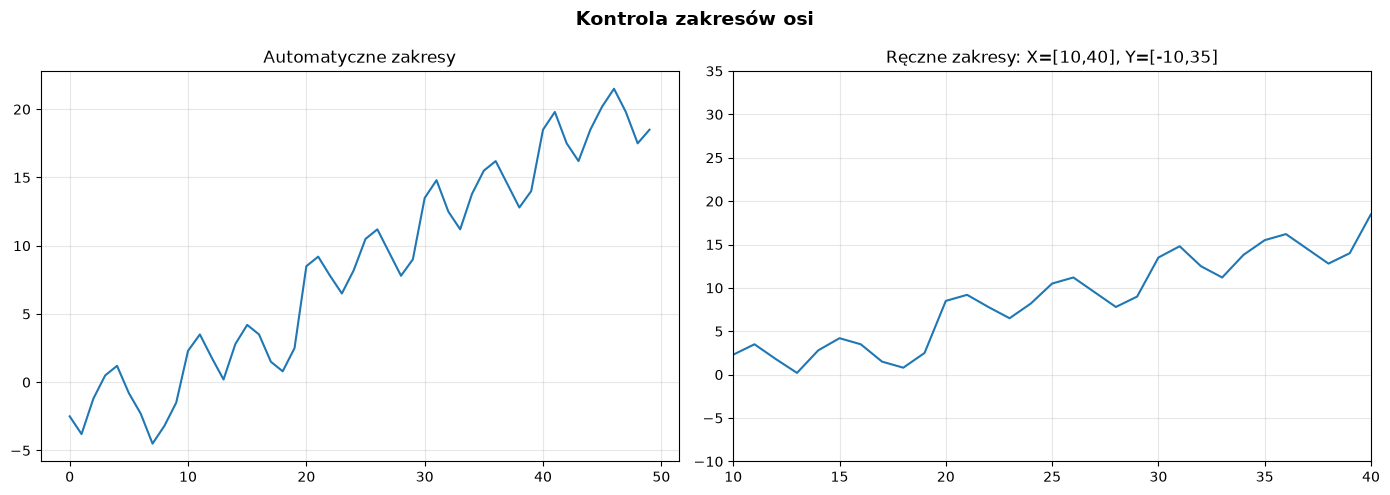

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dane = df_pogoda['temperatura'].head(50)
x = range(len(dane))

# Automatyczne zakresy
axes[0].plot(x, dane)
axes[0].set_title('Automatyczne zakresy', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Ręczne zakresy
axes[1].plot(x, dane)
axes[1].set_xlim(10, 40)           # Zakres osi X
axes[1].set_ylim(-10, 35)          # Zakres osi Y
axes[1].set_title('Ręczne zakresy: X=[10,40], Y=[-10,35]', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Kontrola zakresów osi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

### 1.7 Skale osi (Axis Scales)

Dotychczas używaliśmy **skali liniowej** - gdzie każda jednostka na osi ma taką samą długość. Ale co jeśli dane rosną wykładniczo lub mają ogromny zakres wartości?

#### Historia z laboratorium mikrobiologicznego

Kolega biolog poprosił Cię o pomoc:

> "Monitoruję **wzrost bakterii** w czasie. Na początku jest ich 10, po godzinie 100, po dwóch 1000, po trzech 10000... Po 8 godzinach mam już 100 milionów! Na zwykłym wykresie wszystkie wartości z pierwszych godzin są **niewidoczne** - wykres wygląda jak płaska linia przy 0, a potem nagle strzela w górę. Jak to naprawić?"

Odpowiedź: **Skala logarytmiczna (`log`)!**

---

#### Co to są skale osi?

**Skala osi** określa, jak wartości są **mapowane na fizyczną przestrzeń** wykresu.

**Matplotlib obsługuje 4 główne skale:**

1. **Linear (liniowa)** - domyślna
   - Proporcjonalna: różnica między 10 a 20 to tyle samo miejsca co między 1000 a 1010
   - **Kiedy używać:** Większość standardowych danych

2. **Log (logarytmiczna)**
   - Każda potęga 10 zajmuje tyle samo miejsca (10, 100, 1000, 10000...)
   - **Kiedy używać:** 
     - Dane wykładnicze (wzrost bakterii, populacja, epidemie)
     - Ogromne zakresy wartości (od 1 do 1 000 000)
     - Procesy multiplikatywne (ceny akcji, inflacja)

3. **Symlog (symmetrical log)** - logarytm symetryczny
   - Jak log, ale działa też dla **wartości ujemnych**!
   - Wokół zera (w zakresie `linthresh`) działa liniowo
   - **Kiedy używać:**
     - Dane z wartościami dodatnimi i ujemnymi (zyski/straty)
     - Dane skupione wokół zera, ale z ekstremami

4. **Logit**
   - Odwrotność funkcji logistycznej
   - **Kiedy używać:**
     - Prawdopodobieństwa (0-1)
     - Proporcje, współczynniki (np. konwersja 0-100%)
     - Dane wysycone (blisko 0 lub 1)

**Zmiana skali:**
```python
ax.set_yscale('log')        # Skala Y
ax.set_xscale('linear')     # Skala X
# LUB krócej:
plt.yscale('log')
plt.xscale('linear')
```

---

### 🔍 Czym jest skala LOGIT i dlaczego jest potrzebna?

**Problem ze skalą liniową dla proporcji (0-1):**

Dane takie jak prawdopodobieństwa, współczynniki konwersji, procenty sukcesu mają zakres **0-1** (lub 0-100%).  
Na **skali liniowej** są **ściśnięte przy krańcach** - zmiany z 0.001 → 0.01 lub 0.99 → 0.999 są **niewidoczne**, mimo że są BARDZO istotne!

**Przykład:**
- Skuteczność reklamy wzrosła z **1%** do **10%** → wzrost 10-krotny! 🎯
- Skuteczność wzrosła z **50%** do **59%** → wzrost o 9 punktów procentowych

Na skali liniowej oba wyglądają podobnie (różnica ~0.09), ale **pierwszy to rewolucja, drugi to drobna poprawa!**

---

### 📚 Funkcje sigmoid i logit - dwa narzędzia do różnych celów

**1. Funkcja SIGMOID (logistyczna) - kompresja do zakresu 0-1:**

$$f(x) = \frac{1}{(1 + e^{-x})}$$

**Cel:** Zmapować DOWOLNE wartości (od -∞ do +∞) → zakres 0-1

**Zastosowania:**
- Wyjście sieci neuronowych (klasyfikacja binarna)
- Przekształcenie log-odds na prawdopodobieństwa w regresji logistycznej
- Wszędzie gdzie potrzebujesz "ścisnąć" wartości do przedziału 0-1

**Efekt:** Wartości skrajne (bardzo duże dodatnie/ujemne) są "ściskane" bliżej 0 lub 1

---

**2. Funkcja LOGIT - rozciąganie proporcji na pełną oś:**

$$\text{logit}(p) = \log\left(\frac{p}{1-p}\right)$$

**Cel:** Zmapować proporcje (0-1) → pełna oś rzeczywista (-∞ do +∞)

**Zastosowania:**
- **SKALA WYKRESU** `set_yscale('logit')` - aby wartości przy krańcach były widoczne!
- Regresja logistyczna (po stronie modelu liniowego)
- Analiza danych gdzie zmiany przy 0.001 i 0.999 są ważne

**Efekt:** Wartości blisko 0 i 1 są "rozciągane" (małe zmiany dają duże różnice w logit)

---

**Sigmoid i Logit to odwrotności matematyczne:**

- `sigmoid(logit(p)) = p`
- `logit(sigmoid(x)) = x`

Ale **NIE** rozwiązują nawzajem swoich "problemów" - każde ma swoje ZASTOSOWANIE:

| Funkcja | Wejście | Wyjście | Kiedy używać |
|---------|---------|---------|-------------|
| **Sigmoid** | Dowolne (-∞, +∞) | Proporcje (0, 1) | Chcesz SKOMPRESOWAĆ wartości do 0-1 |
| **Logit** | Proporcje (0, 1) | Dowolne (-∞, +∞) | Chcesz ROZCIĄGNĄĆ proporcje dla lepszej widoczności |

**Zobaczmy na wykresach:**

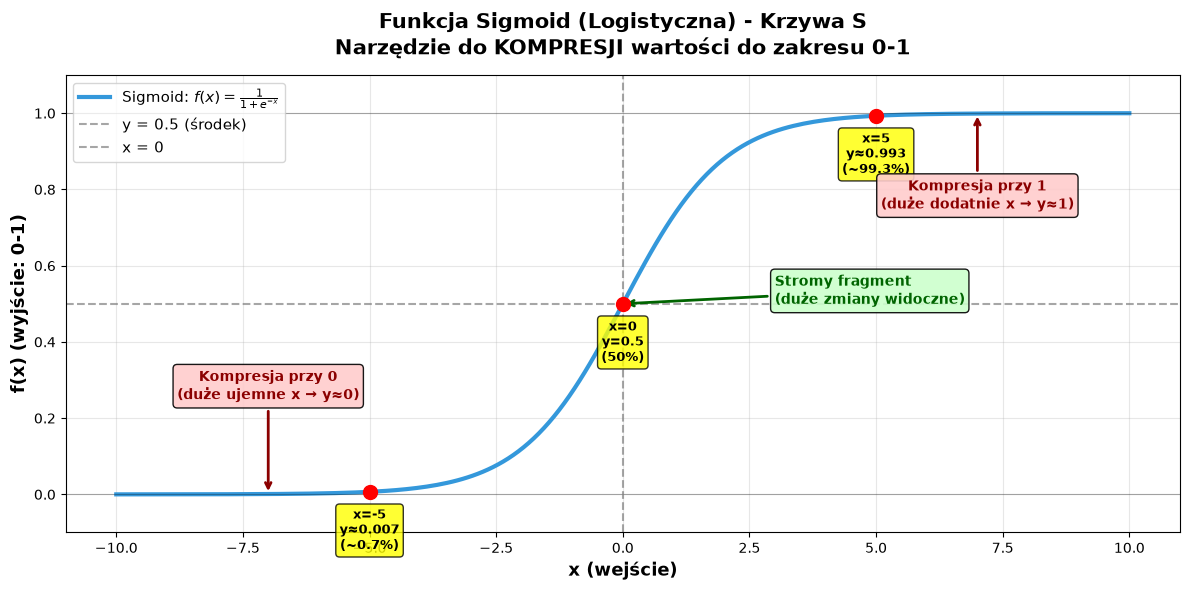

📊 CO WIDZIMY?

🎯 CEL SIGMOID:
   - Zmapować DOWOLNE wartości (x ∈ ℝ) na zakres 0-1
   - Używane w ML: wyjście sieci neuronowej, prawdopodobieństwa

📊 JAK DZIAŁA:
   - Wartości bardzo ujemne (x < -5): sigmoid ≈ 0
   - Wartości bardzo dodatnie (x > 5): sigmoid ≈ 1
   - Wartości przy x=0: sigmoid = 0.5 (środek)

🔵 Efekt kompresji:
   - Zmiana x: -10 → -5 daje wzrost y o ~0.007 (z ~0 do 0.007)
   - Zmiana x: -2 → 2 daje wzrost y o ~0.76 (z 0.12 do 0.88)
   - Zmiana x: 5 → 10 daje wzrost y o ~0.007 (z 0.993 do ~1)
   - Krańce (|x| > 5) są 'spłaszczone' - sigmoid tam wolno rośnie

💡 To NIE jest problem, to FUNKCJA tego narzędzia:
   - Sigmoid KOMPRESUJE wartości do 0-1
   - Jeśli MASZ proporcje 0-1 i chcesz je ROZCIĄGNĄĆ → użyj LOGIT (następny wykres)


In [34]:
# Wizualizacja funkcji SIGMOID (logistycznej)
# Funkcja: f(x) = 1 / (1 + e^(-x))

# Generuj punkty X od -10 do 10 (200 punktów)
X = np.linspace(-10, 10, 200)  # linspace(start, stop, liczba_punktów)
Y = 1 / (1 + np.exp(-X))       # Funkcja sigmoid

# Utwórz wykres
plt.figure(figsize=(12, 6))
plt.plot(X, Y, linewidth=3, color='#3498db', label='Sigmoid: $f(x) = \\frac{1}{1 + e^{-x}}$')

# Dodaj linie pomocnicze
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='y = 0.5 (środek)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
plt.axhline(y=1, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='x = 0')

# Zaznacz kluczowe punkty
kluczowe_punkty = [
    (-5, 1/(1+np.exp(5)), 'x=-5\ny≈0.007\n(~0.7%)'),
    (0, 0.5, 'x=0\ny=0.5\n(50%)'),
    (5, 1/(1+np.exp(-5)), 'x=5\ny≈0.993\n(~99.3%)')
]

for x, y, label in kluczowe_punkty:
    plt.plot(x, y, 'ro', markersize=10, zorder=5)
    plt.annotate(label, xy=(x, y), xytext=(x, y-0.15),
                fontsize=9, ha='center', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# Adnotacje pokazujące kompresję
plt.annotate('Kompresja przy 0\n(duże ujemne x → y≈0)',
            xy=(-7, 0.001), xytext=(-7, 0.25),
            fontsize=10, ha='center', fontweight='bold', color='darkred',
            bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=2))

plt.annotate('Kompresja przy 1\n(duże dodatnie x → y≈1)',
            xy=(7, 0.999), xytext=(7, 0.75),
            fontsize=10, ha='center', fontweight='bold', color='darkred',
            bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=2))

plt.annotate('Stromy fragment\n(duże zmiany widoczne)',
            xy=(0, 0.5), xytext=(3, 0.5),
            fontsize=10, ha='left', fontweight='bold', color='darkgreen',
            bbox=dict(boxstyle='round', facecolor='#ccffcc', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2))

# Stylizacja
plt.xlabel('x (wejście)', fontsize=13, fontweight='bold')
plt.ylabel('f(x) (wyjście: 0-1)', fontsize=13, fontweight='bold')
plt.title('Funkcja Sigmoid (Logistyczna) - Krzywa S\nNarzędzie do KOMPRESJI wartości do zakresu 0-1',
         fontsize=15, fontweight='bold', pad=15)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=11)
plt.ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()

print("📊 CO WIDZIMY?")
print("\n🎯 CEL SIGMOID:")
print("   - Zmapować DOWOLNE wartości (x ∈ ℝ) na zakres 0-1")
print("   - Używane w ML: wyjście sieci neuronowej, prawdopodobieństwa")
print("\n📊 JAK DZIAŁA:")
print("   - Wartości bardzo ujemne (x < -5): sigmoid ≈ 0")
print("   - Wartości bardzo dodatnie (x > 5): sigmoid ≈ 1")
print("   - Wartości przy x=0: sigmoid = 0.5 (środek)")
print("\n🔵 Efekt kompresji:")
print("   - Zmiana x: -10 → -5 daje wzrost y o ~0.007 (z ~0 do 0.007)")
print("   - Zmiana x: -2 → 2 daje wzrost y o ~0.76 (z 0.12 do 0.88)")
print("   - Zmiana x: 5 → 10 daje wzrost y o ~0.007 (z 0.993 do ~1)")
print("   - Krańce (|x| > 5) są 'spłaszczone' - sigmoid tam wolno rośnie")
print("\n💡 To NIE jest problem, to FUNKCJA tego narzędzia:")
print("   - Sigmoid KOMPRESUJE wartości do 0-1")
print("   - Jeśli MASZ proporcje 0-1 i chcesz je ROZCIĄGNĄĆ → użyj LOGIT (następny wykres)")

Krzywa S "ściska" wartości przy 0 i 1, przez co małe zmiany przy krańcach są trudne do zauważenia.

**Czym jest transformacja LOGIT?**

Logit to **odwrotność** funkcji logistycznej - "rozprostowuje" sigmoidę, "rozciąga wartości ograniczone zakresem 0-1:

$$logit(p) = log(\frac{p}{1-p})$$

Gdzie:
- `p` = proporcja (0-1)
- `p/(1-p)` = **szanse (odds)** (np. 0.9/0.1 = 9 → "9 razy bardziej prawdopodobne")
- `log(szanse)` = logarytm szans

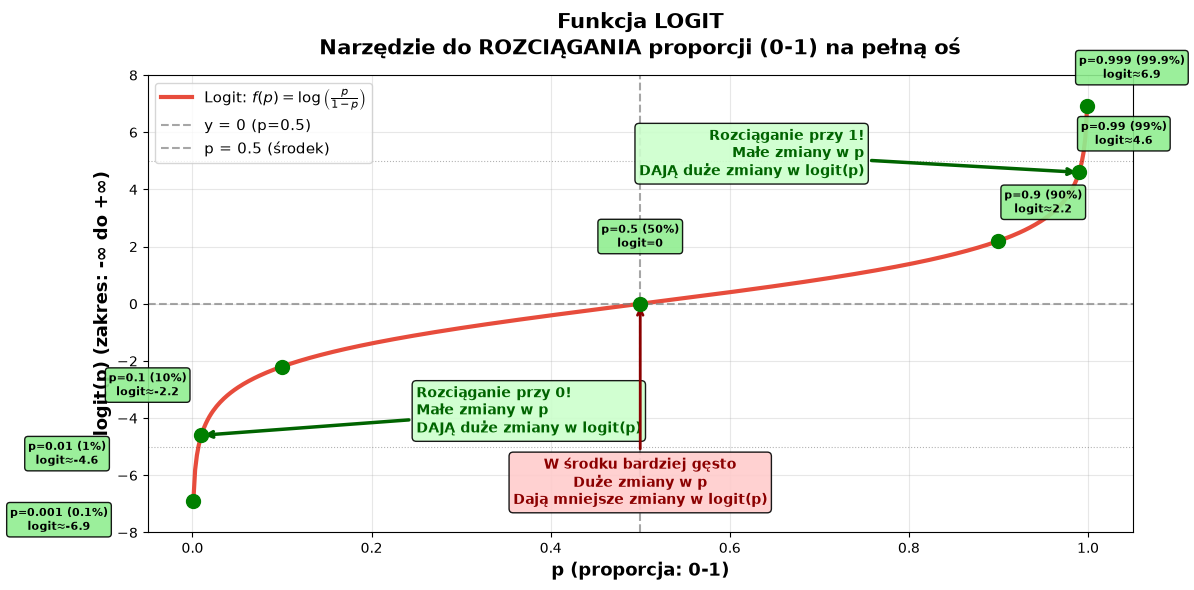

📊 CO WIDZIMY?

🎯 CEL LOGIT:
   - Zmapować proporcje 0-1 na PEŁNĄ oś rzeczywistą (-∞, +∞)
   - Używane jako SKALA WYKRESU: set_yscale('logit')
   - Używane w regresji logistycznej (po stronie modelu liniowego)

📊 JAK DZIAŁA:
   - p blisko 0 (np. 0.001): logit → -∞ (krańce są 'rozciągnięte')
   - p = 0.5: logit = 0 (środek)
   - p blisko 1 (np. 0.999): logit → +∞ (krańce są 'rozciągnięte')

🟢 Efekt rozciągania krańców:
   - Zmiana 0.1% → 1% (p: 0.001 → 0.01): logit Δ = 2.3
   - Zmiana 10% → 90% (p: 0.1 → 0.9): logit Δ = 4.4
   - Zmiana 99% → 99.9% (p: 0.99 → 0.999): logit Δ = 2.3
   - Małe zmiany przy krańcach są WIDOCZNE (duże Δ w logit)!

💡 To NIE jest 'naprawa' sigmoid, to INNE NARZĘDZIE:
   - SIGMOID: kompresuje wartości ℝ → (0,1) - dla ML
   - LOGIT: rozciąga proporcje (0,1) → ℝ - dla SKAL WYKRESÓW
   - Są odwrotnościami: sigmoid(logit(p)) = p, logit(sigmoid(x)) = x
   - Ale mają RÓŻNE ZASTOSOWANIA!

⚠️ Uwaga:
   - Logit NIE ISTNIEJE dla p=0 i p=1 (dzielenie przez 0, log(0)) (asympt

In [36]:
# Wizualizacja funkcji LOGIT (odwrotność sigmoid)
# Funkcja: logit(p) = log(p / (1-p))

# Generuj punkty P od 0.001 do 0.999 (nie można dokładnie 0 ani 1!)
P = np.linspace(0.001, 0.999, 500)  # Proporcje (0-1)
Y = np.log(P / (1 - P))             # Funkcja logit

# Utwórz wykres
plt.figure(figsize=(12, 6))
plt.plot(P, Y, linewidth=3, color='#e74c3c', label='Logit: $f(p) = \\log\\left(\\frac{p}{1-p}\\right)$')

# Dodaj linie pomocnicze
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='y = 0 (p=0.5)')
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='p = 0.5 (środek)')
plt.axhline(y=-5, color='black', linestyle=':', linewidth=0.8, alpha=0.3)
plt.axhline(y=5, color='black', linestyle=':', linewidth=0.8, alpha=0.3)

# Zaznacz kluczowe punkty
kluczowe_punkty = [
    (0.001, np.log(0.001/0.999), 'p=0.001 (0.1%)\nlogit≈-6.9'),
    (0.01, np.log(0.01/0.99), 'p=0.01 (1%)\nlogit≈-4.6'),
    (0.1, np.log(0.1/0.9), 'p=0.1 (10%)\nlogit≈-2.2'),
    (0.5, 0, 'p=0.5 (50%)\nlogit=0'),
    (0.9, np.log(0.9/0.1), 'p=0.9 (90%)\nlogit≈2.2'),
    (0.99, np.log(0.99/0.01), 'p=0.99 (99%)\nlogit≈4.6'),
    (0.999, np.log(0.999/0.001), 'p=0.999 (99.9%)\nlogit≈6.9'),
]

for i, (p, y, label) in enumerate(kluczowe_punkty):
    plt.plot(p, y, 'go', markersize=10, zorder=5)
    # Przesunięcie etykiet żeby się nie nakładały
    if i < 3:
        xytext_offset = (p - 0.15, y - 1)
    elif i == 3:
        xytext_offset = (p, y + 2)
    else:
        xytext_offset = (p + 0.05, y + 1)
    
    plt.annotate(label, xy=(p, y), xytext=xytext_offset,
                fontsize=8, ha='center', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9))

# Adnotacje pokazujące "rozciąganie"
plt.annotate('Rozciąganie przy 0!\nMałe zmiany w p\nDAJĄ duże zmiany w logit(p)',
            xy=(0.01, -4.6), xytext=(0.25, -4.5),
            fontsize=10, ha='left', fontweight='bold', color='darkgreen',
            bbox=dict(boxstyle='round', facecolor='#ccffcc', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2.5))

plt.annotate('Rozciąganie przy 1!\nMałe zmiany w p\nDAJĄ duże zmiany w logit(p)',
            xy=(0.99, 4.6), xytext=(0.75, 4.5),
            fontsize=10, ha='right', fontweight='bold', color='darkgreen',
            bbox=dict(boxstyle='round', facecolor='#ccffcc', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2.5))

plt.annotate('W środku bardziej gęsto\nDuże zmiany w p\nDają mniejsze zmiany w logit(p)',
            xy=(0.5, 0), xytext=(0.5, -7),
            fontsize=10, ha='center', fontweight='bold', color='darkred',
            bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=2))

# Stylizacja
plt.xlabel('p (proporcja: 0-1)', fontsize=13, fontweight='bold')
plt.ylabel('logit(p) (zakres: -∞ do +∞)', fontsize=13, fontweight='bold')
plt.title('Funkcja LOGIT\nNarzędzie do ROZCIĄGANIA proporcji (0-1) na pełną oś',
         fontsize=15, fontweight='bold', pad=15)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=11)
plt.ylim(-8, 8)
plt.xlim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print("📊 CO WIDZIMY?")
print("\n🎯 CEL LOGIT:")
print("   - Zmapować proporcje 0-1 na PEŁNĄ oś rzeczywistą (-∞, +∞)")
print("   - Używane jako SKALA WYKRESU: set_yscale('logit')")
print("   - Używane w regresji logistycznej (po stronie modelu liniowego)")
print("\n📊 JAK DZIAŁA:")
print("   - p blisko 0 (np. 0.001): logit → -∞ (krańce są 'rozciągnięte')")
print("   - p = 0.5: logit = 0 (środek)")
print("   - p blisko 1 (np. 0.999): logit → +∞ (krańce są 'rozciągnięte')")
print("\n🟢 Efekt rozciągania krańców:")
print("   - Zmiana 0.1% → 1% (p: 0.001 → 0.01): logit Δ = 2.3")
print("   - Zmiana 10% → 90% (p: 0.1 → 0.9): logit Δ = 4.4")
print("   - Zmiana 99% → 99.9% (p: 0.99 → 0.999): logit Δ = 2.3")
print("   - Małe zmiany przy krańcach są WIDOCZNE (duże Δ w logit)!")
print("\n💡 To NIE jest 'naprawa' sigmoid, to INNE NARZĘDZIE:")
print("   - SIGMOID: kompresuje wartości ℝ → (0,1) - dla ML")
print("   - LOGIT: rozciąga proporcje (0,1) → ℝ - dla SKAL WYKRESÓW")
print("   - Są odwrotnościami: sigmoid(logit(p)) = p, logit(sigmoid(x)) = x")
print("   - Ale mają RÓŻNE ZASTOSOWANIA!")
print("\n⚠️ Uwaga:")
print("   - Logit NIE ISTNIEJE dla p=0 i p=1 (dzielenie przez 0, log(0)) (asymptoty)")
print("   - Dlatego używamy p ∈ (0.001, 0.999)")
print("   - Na wykresie: krzywa 'ucieka' do -∞ i +∞ przy krańcach")

**Efekt:**
- Wartości blisko 0 i 1 są **rozciągnięte** (widać małe zmiany)
- Wartości w środku (0.3-0.7) są **nieco ściśnięte**
- **Symetryczna** transformacja wokół 0.5

**Kiedy używać LOGIT?**
- ✅ Prawdopodobieństwa (regresja logistyczna)
- ✅ Współczynniki konwersji (marketing)
- ✅ Procenty sukcesu/porażki
- ✅ Dane z zakresu 0-1, gdzie krańce są ważne
- ❌ NIE dla danych poza zakresem 0-1

**Zobaczmy różnicę na przykładzie:**

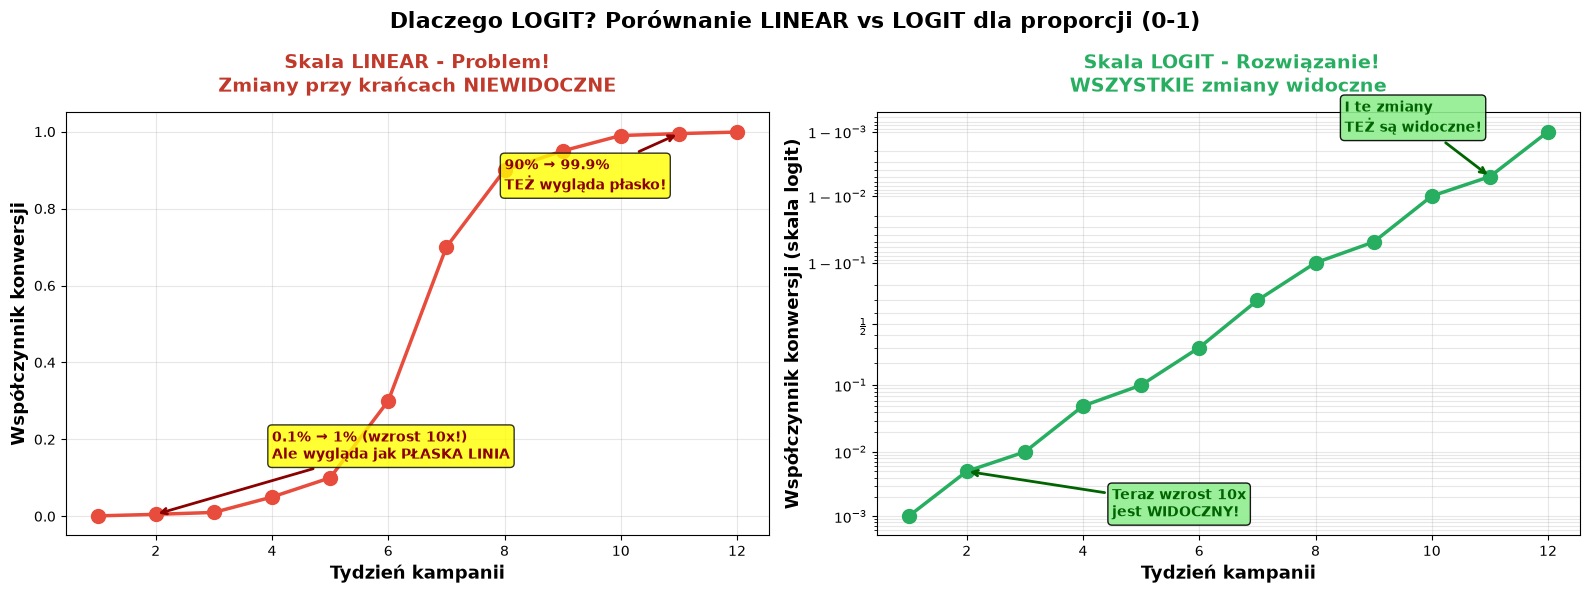

📊 CO WIDZIMY?

❌ SKALA LINEAR (lewa):
   - Tygodnie 1-3 (0.1% → 1% → 5%): Wygląda PŁASKO, ale to wzrost 50-krotny!
   - Tygodnie 10-12 (99% → 99.9%): Też wygląda płasko
   - Wszystko 'dzieje się' w środku (tygodnie 6-7)
   - Nie widać, jak trudno poprawić słabą kampanię (0.1% → 1%)

 SKALA LOGIT (prawa):
   - WSZYSTKIE zmiany są widoczne i proporcjonalne
   - Wzrost z 0.1% → 1% wygląda tak samo jak z 50% → ~90% (oba ~10x)
   - Widać jak trudno przejść z 99% do 99.9%
   - Równomierne rozłożenie - łatwiej analizować trendy

 WNIOSEK:
   Dla proporcji/prawdopodobieństw gdzie krańce (blisko 0 lub 1) są WAŻNE → użyj LOGIT!
   Przykłady: skuteczność reklam, prawdopodobieństwo choroby, współczynnik konwersji


In [37]:
# PORÓWNANIE: SKALA LINEAR vs LOGIT
# Dane: Współczynnik konwersji reklamy w 12 tygodniach
# Wzrost od 0.1% (bardzo słaba kampania) do 99.9% (niemal perfekcyjna)

tygodnie = np.arange(1, 13)
# Dane konwersji: od 0.001 (0.1%) do 0.999 (99.9%)
konwersja = np.array([0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 0.7, 0.9, 0.95, 0.99, 0.995, 0.999])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================
# WYKRES 1: SKALA LINEAR (PROBLEM!)
# ============================================================
axes[0].plot(tygodnie, konwersja, 'o-', markersize=10, linewidth=2.5, color='#e74c3c')
axes[0].set_xlabel('Tydzień kampanii', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Współczynnik konwersji', fontsize=13, fontweight='bold')
axes[0].set_title('Skala LINEAR - Problem!\nZmiany przy krańcach NIEWIDOCZNE', 
                  fontsize=14, fontweight='bold', pad=15, color='#c0392b')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.05, 1.05)

# Adnotacje pokazujące problem
axes[0].annotate('0.1% → 1% (wzrost 10x!)\nAle wygląda jak PŁASKA LINIA',
                xy=(2, 0.005), xytext=(4, 0.15),
                fontsize=10, fontweight='bold', color='darkred',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='darkred', lw=2))

axes[0].annotate('90% → 99.9%\nTEŻ wygląda płasko!',
                xy=(11, 0.995), xytext=(8, 0.85),
                fontsize=10, fontweight='bold', color='darkred',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='darkred', lw=2))

# ============================================================
# WYKRES 2: SKALA LOGIT (ROZWIĄZANIE!)
# ============================================================
axes[1].plot(tygodnie, konwersja, 'o-', markersize=10, linewidth=2.5, color='#27ae60')
axes[1].set_yscale('logit')  # KLUCZOWA LINIA!
axes[1].set_xlabel('Tydzień kampanii', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Współczynnik konwersji (skala logit)', fontsize=13, fontweight='bold')
axes[1].set_title(' Skala LOGIT - Rozwiązanie!\nWSZYSTKIE zmiany widoczne', 
                  fontsize=14, fontweight='bold', pad=15, color='#27ae60')
axes[1].grid(True, alpha=0.3, which='both')

# Adnotacje
axes[1].annotate('Teraz wzrost 10x\njest WIDOCZNY!',
                xy=(2, 0.005), xytext=(4.5, 0.001),
                fontsize=10, fontweight='bold', color='darkgreen',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9),
                arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2))

axes[1].annotate('I te zmiany\nTEŻ są widoczne!',
                xy=(11, 0.995), xytext=(8.5, 0.999),
                fontsize=10, fontweight='bold', color='darkgreen',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9),
                arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2))

plt.suptitle('Dlaczego LOGIT? Porównanie LINEAR vs LOGIT dla proporcji (0-1)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("📊 CO WIDZIMY?")
print("\n❌ SKALA LINEAR (lewa):")
print("   - Tygodnie 1-3 (0.1% → 1% → 5%): Wygląda PŁASKO, ale to wzrost 50-krotny!")
print("   - Tygodnie 10-12 (99% → 99.9%): Też wygląda płasko")
print("   - Wszystko 'dzieje się' w środku (tygodnie 6-7)")
print("   - Nie widać, jak trudno poprawić słabą kampanię (0.1% → 1%)")
print("\n SKALA LOGIT (prawa):")
print("   - WSZYSTKIE zmiany są widoczne i proporcjonalne")
print("   - Wzrost z 0.1% → 1% wygląda tak samo jak z 50% → ~90% (oba ~10x)")
print("   - Widać jak trudno przejść z 99% do 99.9%")
print("   - Równomierne rozłożenie - łatwiej analizować trendy")
print("\n WNIOSEK:")
print("   Dla proporcji/prawdopodobieństw gdzie krańce (blisko 0 lub 1) są WAŻNE → użyj LOGIT!")
print("   Przykłady: skuteczność reklam, prawdopodobieństwo choroby, współczynnik konwersji")

#### Przykład 1: Porównanie 4 skal - wzrost wykładniczy

Zobaczmy **ten sam wykres** z danymi wykładniczymi wyświetlony w **4 różnych skal**:

Problem biologa: dane bakterii rosną od 10 do 100 000 000. Jak to zwizualizować?

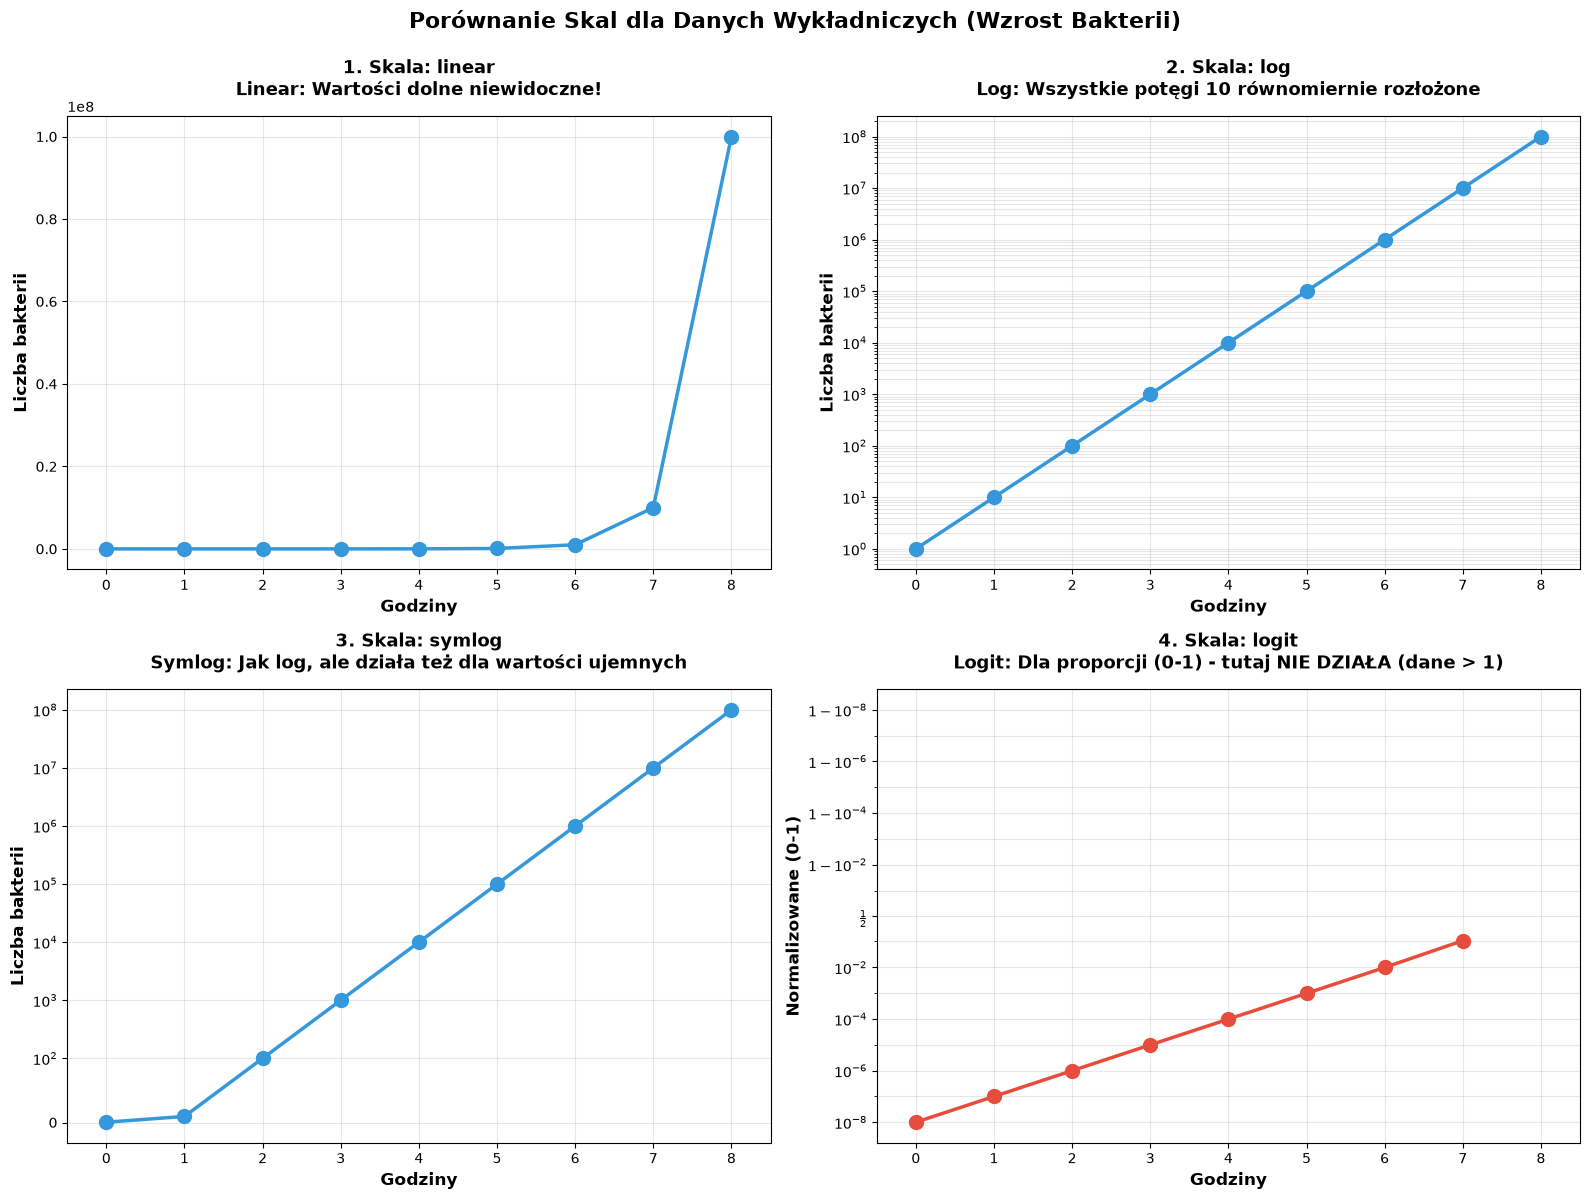

📊 Co widzimy?
   1. LINEAR: Pierwsze wartości (10, 100, 1000) wyglądają jak ZERO! Wszystko zdominowane przez 100M
   2. LOG: Każda potęga 10 zajmuje tyle samo miejsca - WSZYSTKIE wartości widoczne! ✅
   3. SYMLOG: Jak log, ale działa też dla wartości ujemnych (tutaj to samo co log)
   4. LOGIT: Dla proporcji 0-1 (znormalizowaliśmy dane, żeby pokazać)

💡 Wniosek: Dla danych wykładniczych używaj SKALI LOG!


In [38]:
# Generuj dane wykładnicze (wzrost bakterii)
godziny = np.arange(0, 9)
bakterie = 10 ** godziny  # 10, 100, 1000, 10000, ..., 100000000

# Porównanie 4 skal
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

scales = ['linear', 'log', 'symlog', 'logit']
titles = [
    'Linear: Wartości dolne niewidoczne!',
    'Log: Wszystkie potęgi 10 równomiernie rozłożone',
    'Symlog: Jak log, ale działa też dla wartości ujemnych',
    'Logit: Dla proporcji (0-1) - tutaj NIE DZIAŁA (dane > 1)'
]

for i, (ax, scale, title) in enumerate(zip(axes, scales, titles)):
    # Wykres
    if scale == 'logit':
        # Logit wymaga wartości 0-1, więc znormalizujmy
        ax.plot(godziny, bakterie / bakterie.max(), 'o-', markersize=10, linewidth=2.5, color='#e74c3c')
        ax.set_ylabel('Normalizowane (0-1)', fontsize=12, fontweight='bold')
    else:
        ax.plot(godziny, bakterie, 'o-', markersize=10, linewidth=2.5, color='#3498db')
        ax.set_ylabel('Liczba bakterii', fontsize=12, fontweight='bold')
    
    # Ustaw skalę
    try:
        if scale == 'symlog':
            ax.set_yscale(scale, linthresh=100)  # linthresh=100: liniowa skala od -100 do 100
        else:
            ax.set_yscale(scale)
    except:
        pass  # Logit może nie działać dla niektórych danych
    
    # Stylizacja
    ax.set_xlabel('Godziny', fontsize=12, fontweight='bold')
    ax.set_title(f'{i+1}. Skala: {scale}\n{title}', fontsize=13, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, which='both')
    ax.set_xlim(-0.5, 8.5)

plt.suptitle('Porównanie Skal dla Danych Wykładniczych (Wzrost Bakterii)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("📊 Co widzimy?")
print("   1. LINEAR: Pierwsze wartości (10, 100, 1000) wyglądają jak ZERO! Wszystko zdominowane przez 100M")
print("   2. LOG: Każda potęga 10 zajmuje tyle samo miejsca - WSZYSTKIE wartości widoczne! ✅")
print("   3. SYMLOG: Jak log, ale działa też dla wartości ujemnych (tutaj to samo co log)")
print("   4. LOGIT: Dla proporcji 0-1 (znormalizowaliśmy dane, żeby pokazać)")
print("\n💡 Wniosek: Dla danych wykładniczych używaj SKALI LOG!")

#### Przykład 2: Praktyczne zastosowania różnych skal

Zobaczmy **3 realne przykłady**, kiedy używać każdej skali:

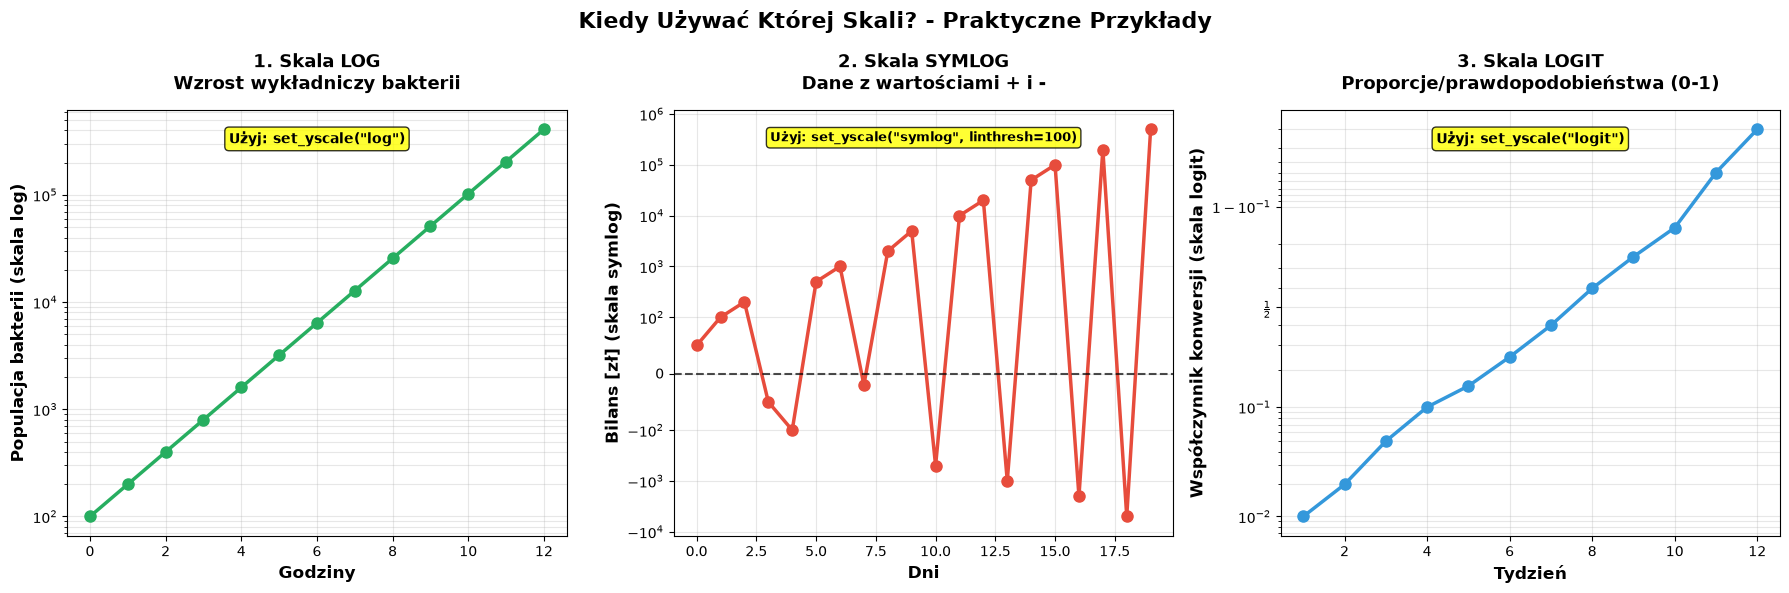

✅ Przykład 1 - LOG:
   - Dane: Wzrost wykładniczy (bakterie: 100 → 409600)
   - Dlaczego log: Ogromny zakres wartości, wzrost multiplikatywny
   - Efekt: Wszystkie wartości widoczne, podwojenie zawsze wygląda tak samo

✅ Przykład 2 - SYMLOG:
   - Dane: Bilans finansowy (od -5000 zł do +500000 zł)
   - Dlaczego symlog: Dane z wartościami + i -, ogromny zakres
   - linthresh=100: Wartości od -100 do +100 w skali liniowej (blisko zera)
   - Efekt: Zarówno duże zyski jak i straty widoczne!

✅ Przykład 3 - LOGIT:
   - Dane: Współczynnik konwersji (0.01 = 1% do 0.98 = 98%)
   - Dlaczego logit: Proporcje (0-1), wartości blisko granic (0 i 1)
   - Efekt: Lepiej widać zmiany gdy już jesteś blisko 0% lub 100%

💡 Zasada:
   LOG → dane wykładnicze, ogromne zakresy (tylko wartości > 0)
   SYMLOG → jak log, ale działa dla wartości ujemnych
   LOGIT → proporcje, prawdopodobieństwa (0-1)


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ============================================================
# PRZYKŁAD 1: SKALA LOG - Wzrost populacji bakterii w czasie
# ============================================================
godziny = np.arange(0, 13)
populacja = 100 * (2 ** godziny)  # Podwojenie co godzinę: 100, 200, 400, 800...

axes[0].plot(godziny, populacja, 'o-', markersize=8, linewidth=2.5, color='#27ae60')
axes[0].set_yscale('log')  # KLUCZOWA LINIA!
axes[0].set_xlabel('Godziny', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Populacja bakterii (skala log)', fontsize=12, fontweight='bold')
axes[0].set_title('1. Skala LOG\nWzrost wykładniczy bakterii', fontsize=13, fontweight='bold', pad=15)
axes[0].grid(True, alpha=0.3, which='both')
axes[0].text(0.5, 0.95, 'Użyj: set_yscale(\"log\")', transform=axes[0].transAxes,
             fontsize=10, fontweight='bold', ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# ============================================================
# PRZYKŁAD 2: SKALA SYMLOG - Bilans finansowy (zyski i straty)
# ============================================================
dni = np.arange(0, 20)
# Dane z wartościami dodatnimi (zysk) i ujemnymi (strata)
bilans = np.array([50, 100, 200, -50, -100, 500, 1000, -20, 2000, 5000, 
                   -500, 10000, 20000, -1000, 50000, 100000, -2000, 200000, -5000, 500000])

axes[1].plot(dni, bilans, 'o-', markersize=8, linewidth=2.5, color='#e74c3c')
axes[1].set_yscale('symlog', linthresh=100)  # KLUCZOWA LINIA! linthresh=100
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)  # Linia zera
axes[1].set_xlabel('Dni', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Bilans [zł] (skala symlog)', fontsize=12, fontweight='bold')
axes[1].set_title('2. Skala SYMLOG\nDane z wartościami + i -', fontsize=13, fontweight='bold', pad=15)
axes[1].grid(True, alpha=0.3, which='both')
axes[1].text(0.5, 0.95, 'Użyj: set_yscale(\"symlog\", linthresh=100)', transform=axes[1].transAxes,
             fontsize=9, fontweight='bold', ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# ============================================================
# PRZYKŁAD 3: SKALA LOGIT - Współczynnik konwersji (proporcje 0-1)
# ============================================================
tydzien = np.arange(1, 13)
# Współczynnik konwersji: 0.01 (1%) do 0.99 (99%)
konwersja = np.array([0.01, 0.02, 0.05, 0.10, 0.15, 0.25, 0.40, 0.60, 0.75, 0.85, 0.95, 0.98])

axes[2].plot(tydzien, konwersja, 'o-', markersize=8, linewidth=2.5, color='#3498db')
axes[2].set_yscale('logit')  # KLUCZOWA LINIA!
axes[2].set_xlabel('Tydzień', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Współczynnik konwersji (skala logit)', fontsize=12, fontweight='bold')
axes[2].set_title('3. Skala LOGIT\nProporcje/prawdopodobieństwa (0-1)', fontsize=13, fontweight='bold', pad=15)
axes[2].grid(True, alpha=0.3, which='both')
axes[2].text(0.5, 0.95, 'Użyj: set_yscale(\"logit\")', transform=axes[2].transAxes,
             fontsize=10, fontweight='bold', ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

plt.suptitle('Kiedy Używać Której Skali? - Praktyczne Przykłady', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("✅ Przykład 1 - LOG:")
print("   - Dane: Wzrost wykładniczy (bakterie: 100 → 409600)")
print("   - Dlaczego log: Ogromny zakres wartości, wzrost multiplikatywny")
print("   - Efekt: Wszystkie wartości widoczne, podwojenie zawsze wygląda tak samo\n")

print("✅ Przykład 2 - SYMLOG:")
print("   - Dane: Bilans finansowy (od -5000 zł do +500000 zł)")
print("   - Dlaczego symlog: Dane z wartościami + i -, ogromny zakres")
print("   - linthresh=100: Wartości od -100 do +100 w skali liniowej (blisko zera)")
print("   - Efekt: Zarówno duże zyski jak i straty widoczne!\n")

print("✅ Przykład 3 - LOGIT:")
print("   - Dane: Współczynnik konwersji (0.01 = 1% do 0.98 = 98%)")
print("   - Dlaczego logit: Proporcje (0-1), wartości blisko granic (0 i 1)")
print("   - Efekt: Lepiej widać zmiany gdy już jesteś blisko 0% lub 100%\n")

print("💡 Zasada:")
print("   LOG → dane wykładnicze, ogromne zakresy (tylko wartości > 0)")
print("   SYMLOG → jak log, ale działa dla wartości ujemnych")
print("   LOGIT → proporcje, prawdopodobieństwa (0-1)")

---

### 🔍 Co to jest `linthresh` w skali SYMLOG?

**Problem:** Skala logarytmiczna NIE działa dla zera i wartości ujemnych!

- `log(0)` = -∞ (niezdefiniowane)
- `log(-5)` = liczba urojona (niezdefiniowane w ℝ)

**Rozwiązanie:** SYMLOG = **SYM**metrical **LOG**arithm - logarytm symetryczny

---

#### Jak działa SYMLOG?

Skala SYMLOG dzieli oś na **3 obszary:**

```
        OBSZAR UJEMNY         LINIOWY           DODATNI
      (logarytmiczny)      wokół zera      (logarytmiczny)
           ◄──────────────►|◄──────►|◄──────────────►
-1000  -100  -10    -linthresh  0  +linthresh    +10  +100  +1000
```

**Parametr `linthresh` (linear threshold):**
- Określa **GDZIE kończy się obszar liniowy**, a zaczyna logarytmiczny
- Wartości w przedziale `[-linthresh, +linthresh]` są w **skali liniowej**
- Wartości poza tym przedziałem są w **skali logarytmicznej**

---

#### Przykład: `linthresh=100`

```python
ax.set_yscale('symlog', linthresh=100)
```

**Co się dzieje:**

| Zakres wartości | Skala | Jak wygląda |
|----------------|-------|-------------|
| y < -100 | **Logarytmiczna** | -1000, -500, -200, -100 zajmują coraz więcej miejsca |
| -100 ≤ y ≤ +100 | **Liniowa** | -100, -50, 0, 50, 100 równomiernie rozłożone |
| y > +100 | **Logarytmiczna** | 100, 200, 500, 1000 zajmują coraz mniej miejsca |

---

#### Dlaczego to jest potrzebne?

**Bez obszaru liniowego (gdyby symlog działał wszędzie logarytmicznie):**
- Wartości blisko zera (-5, -1, 0, 1, 5) byłyby BARDZO rozciągnięte
- Wykres byłby nieczytelny w okolicy zera
- `log(0.001)` = -7, `log(0.1)` = -2, `log(1)` = 0 → ogromne odległości!

**Z `linthresh`:**
- Wartości blisko zera są w skali liniowej (czytelne!)
- Ekstremalne wartości (-10000, +1000000) są w skali log (widoczne!)

---

#### Jak dobrać `linthresh`?

**Zasada:** `linthresh` powinien być **około 1-10% maksymalnej wartości** (w wartości bezwzględnej)

**Przykłady:**

| Dane | Zakres | Dobry `linthresh` |
|------|--------|------------------|
| Bilans finansowy | -5000 do +500000 | `100` lub `1000` |
| Anomalie temperatury | -2 do +50 | `0.1` lub `1` |
| Zmiany kursu walut | -1000 do +10000 | `10` lub `100` |

**Zbyt mały `linthresh` (np. 1):**
- Prawie cały wykres w skali log → wartości blisko zera nadal rozciągnięte

**Zbyt duży `linthresh` (np. 100000):**
- Prawie cały wykres w skali liniowej → tracimy korzyści ze skali log dla dużych wartości

---

**💡 Podsumowanie:**
- **SYMLOG = LOG + obszar liniowy wokół zera**
- **`linthresh`** = granica gdzie kończy się obszar liniowy
- Pozwala wyświetlać dane z wartościami dodatnimi, ujemnymi i zerem na jednym wykresie!
- Używaj gdy masz ogromny zakres wartości, ale część danych skupiona wokół zera

**Kluczowe spostrzeżenia - Skale Osi (Axis Scales):**

✅ **Kiedy używać której skali:**

**1. LINEAR (domyślna)** - `ax.set_yscale('linear')`
- ✅ Większość standardowych danych
- ✅ Dane w podobnym zakresie (np. temperatury 10-30°C)
- ✅ Wzrost liniowy lub umiarkowany
- ❌ NIE używaj dla danych wykładniczych (będzie nieczytelne)

**2. LOG (logarytmiczna)** - `ax.set_yscale('log')`
- ✅ Dane wykładnicze (wzrost bakterii, populacja, epidemie)
- ✅ Ogromne zakresy wartości (od 1 do 1 000 000)
- ✅ Procesy multiplikatywne (ceny akcji, inflacja, zwroty inwestycyjne)
- ✅ Gdy interesuje Cię **tempo wzrostu** (% zmiana), nie wartość absolutna
- ❌ NIE działa dla wartości ≤ 0 (log(0) i log(ujemne) są niezdefiniowane!)

**3. SYMLOG (symmetrical logarithmic)** - `ax.set_yscale('symlog', linthresh=X)`
- ✅ Dane z wartościami **dodatnimi I ujemnymi** (zyski/straty, anomalie)
- ✅ Jak log, ale działa dla ujemnych!
- ✅ Ogromny zakres, ale skupiony wokół zera
- 🔧 **linthresh** - zakres wokół zera gdzie działa liniowo (np. `linthresh=100`: od -100 do +100 liniowo)
- 💡 Przykład: bilans finansowy od -10000 zł do +1000000 zł

**4. LOGIT** - `ax.set_yscale('logit')`
- ✅ **Tylko dla wartości 0-1** (proporcje, prawdopodobieństwa, współczynniki)
- ✅ Dane wysycone blisko 0 lub 1 (np. konwersja 98%, 99%, 99.9%)
- ✅ Lepiej pokazuje zmiany gdy jesteś blisko granic (0% lub 100%)
- ❌ NIE działa dla wartości poza przedziałem (0, 1)!
- 💡 Przykład: współczynnik konwersji, wskaźnik sukcesu, proporcje

---

📊 **Kompletny szablon:**
```python
fig, ax = plt.subplots(figsize=(10, 6))

# Dane
x = np.arange(0, 10)
y = 10 ** x  # Dane wykładnicze

# Wykres
ax.plot(x, y, 'o-', linewidth=2)

# USTAW SKALĘ (wybierz jedną):
ax.set_yscale('linear')                    # Domyślna
ax.set_yscale('log')                       # Dla danych wykładniczych
ax.set_yscale('symlog', linthresh=100)    # Dla + i -, liniowo od -100 do 100
ax.set_yscale('logit')                     # Dla proporcji 0-1

# Możesz też dla osi X:
ax.set_xscale('log')

# Grid dla lepszej czytelności
ax.grid(True, alpha=0.3, which='both')  # which='both' pokazuje major i minor

plt.show()
```

⚠️ **Częste błędy:**

**1. Log scale z wartościami ≤ 0:**
```python
# ❌ BŁĄD: log(0) lub log(ujemne) nie istnieje!
y = [0, 1, 10, 100]
ax.set_yscale('log')  # Dostaniesz błąd lub dziwny wykres
```
**Rozwiązanie:** Użyj `symlog` lub dodaj małą wartość: `y = y + 0.001`

**2. Logit dla wartości poza (0, 1):**
```python
# ❌ BŁĄD: logit działa tylko dla 0 < wartość < 1
y = [0.5, 1.5, 2.0]  # 1.5 i 2.0 są poza zakresem!
ax.set_yscale('logit')
```
**Rozwiązanie:** Znormalizuj dane: `y_norm = y / y.max()`

**3. Linthresh za duży w symlog:**
```python
# ⚠️ Źle dobrany linthresh
y = range(-1000, 1000)
ax.set_yscale('symlog', linthresh=10000)  # Za duży! Cały wykres będzie liniowy
```
**Zasada:** `linthresh` powinien być ~1-10% zakresu danych

---

💡 **Best Practices:**

**1. Gdy w wątpliwości:**
- Zacznij od LINEAR
- Jeśli zobaczysz że dane są nieczytelne (wszystko przy 0 a jeden punkt w górze) → spróbuj LOG

**2. Zawsze dodawaj grid:**
```python
ax.grid(True, alpha=0.3, which='both')  # which='both' dla major i minor grid
```

**3. Dla skali log - używaj minor grid:**
```python
ax.set_yscale('log')
ax.grid(True, alpha=0.3, which='both')  # Pokazuje potęgi pośrednie (20, 30, ..., 200, 300...)
```

**4. Label osi zawsze z informacją o skali (jeśli nie jest linear):**
```python
ax.set_ylabel('Populacja bakterii (skala log)', fontsize=12)
```

**5. Test różnych skal:**
```python
# Stwórz kilka wykresów obok siebie z różnymi skalami - zobacz co działa najlepiej!
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].set_yscale('linear')
axes[1].set_yscale('log')
axes[2].set_yscale('symlog', linthresh=10)
```

---

🎯 **Decyzja drzewo:**
```
Masz dane?
│
├─ Tylko wartości > 0?
│  │
│  ├─ Tak
│  │  │
│  │  ├─ Wzrost wykładniczy / ogromny zakres (1 do 1M)?
│  │  │  └─> Użyj LOG ✅
│  │  │
│  │  ├─ Proporcje 0-1 (np. 0.01, 0.5, 0.99)?
│  │  │  └─> Użyj LOGIT ✅
│  │  │
│  │  └─ Normalny zakres?
│  │     └─> Użyj LINEAR ✅
│  │
│  └─ Nie (mam wartości ujemne)
│     │
│     ├─ Ogromny zakres dodatnich I ujemnych?
│     │  └─> Użyj SYMLOG ✅
│     │
│     └─ Normalny zakres
│        └─> Użyj LINEAR ✅
```

---

### 1.8 Ticki i etykiety ticków (`set_xticks`, `set_xticklabels`)

Kontroluj gdzie pojawiają się znaczniki i jak są opisane.

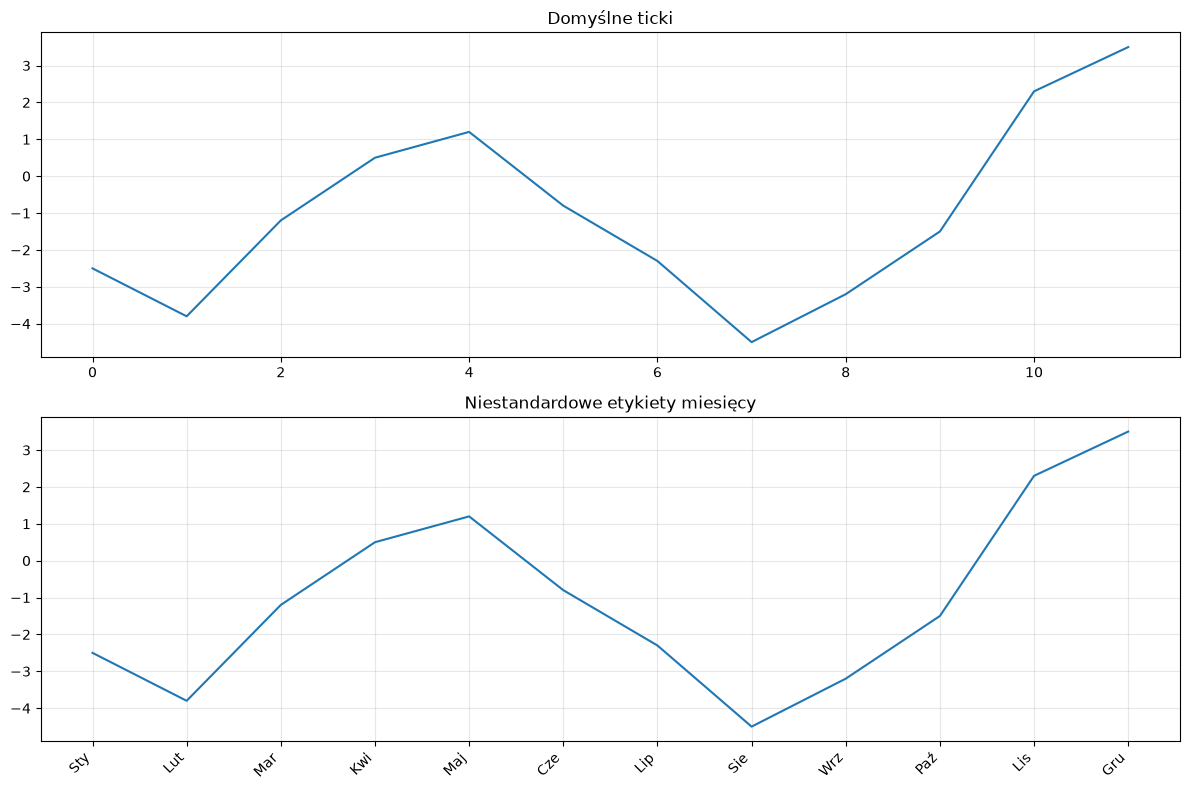

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

dane = df_pogoda['temperatura'].head(12)
miesiace = ['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze', 
            'Lip', 'Sie', 'Wrz', 'Paź', 'Lis', 'Gru']

# Domyślne ticki
axes[0].plot(range(12), dane)
axes[0].set_title('Domyślne ticki', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Niestandardowe ticki i etykiety
axes[1].plot(range(12), dane)
axes[1].set_xticks(range(12))              # Pozycje ticków
axes[1].set_xticklabels(miesiace,          # Etykiety
                        rotation=45,        # Obrót
                        ha='right')         # Wyrównanie (horizontal alignment)
axes[1].set_title('Niestandardowe etykiety miesięcy', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.9 Kompletny wykres z wszystkimi elementami

Połączmy wszystko razem:

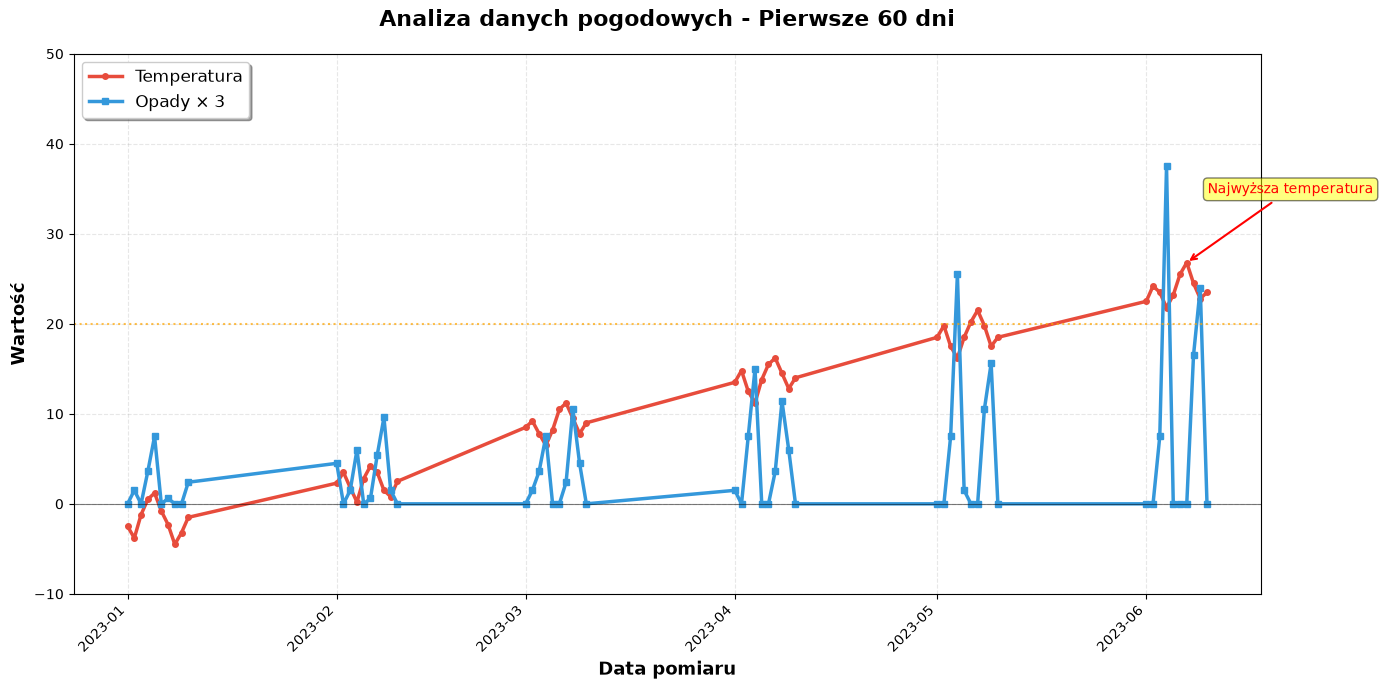

In [40]:
# Profesjonalny wykres z wszystkimi elementami
fig, ax = plt.subplots(figsize=(14, 7))

# Dane
dane = df_pogoda.head(60)

# Wykresy
line1 = ax.plot(dane['data'], dane['temperatura'], 
                color='#e74c3c', linewidth=2.5, label='Temperatura', marker='o', markersize=4)
line2 = ax.plot(dane['data'], dane['opady']*3, 
                color='#3498db', linewidth=2.5, label='Opady × 3', marker='s', markersize=4)

# Tytuł
ax.set_title('Analiza danych pogodowych - Pierwsze 60 dni', 
             fontsize=16, fontweight='bold', pad=20)

# Opisy osi
ax.set_xlabel('Data pomiaru', fontsize=13, fontweight='bold')
ax.set_ylabel('Wartość', fontsize=13, fontweight='bold')

# Legenda
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, fancybox=True)

# Siatka
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

# Zakres osi Y
ax.set_ylim(-10, 50)

# Obrót etykiet osi X
plt.xticks(rotation=45, ha='right')

# Dodaj linie referencyjne
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)  # Linia przy 0
ax.axhline(y=20, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='Ref: 20°C')

# Adnotacja
ax.annotate('Najwyższa temperatura', 
            xy=(dane.loc[dane['temperatura'].idxmax(), 'data'], 
                dane['temperatura'].max()),
            xytext=(15, 50), textcoords='offset points',
            fontsize=10, color='red',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.tight_layout()
plt.show()

---
## Ćwiczenie 2.11 (w trakcie) - Kompletny wykres

**Cel:** Stworzyć profesjonalny wykres z wszystkimi elementami.

**Zadanie:**
1. Użyj danych sprzedażowych
2. Utwórz wykres liniowy pokazujący wartość sprzedaży w czasie (pierwsze 50 transakcji)
3. Dodaj WSZYSTKIE elementy:
   - Tytuł (duży, pogrubiony)
   - Opisy osi z jednostkami
   - Siatkę (tylko poziomą)
   - Czerwony kolor linii z markerami
   - Linię referencyjną przy średniej wartości sprzedaży
4. Obróć etykiety osi X o 45°

**Czas:** 15 minut

In [14]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
fig, ax = plt.subplots(figsize=(14, 7))

# Dane
dane = df_sprzedaz.head(50)

# Wykres
ax.plot(dane['data'], dane['wartosc_sprzedazy'], 
        color='red', linewidth=2, marker='o', markersize=5, label='Wartość sprzedaży')

# Tytuł
ax.set_title('Wartość sprzedaży - pierwsze 50 transakcji', 
             fontsize=16, fontweight='bold', pad=20)

# Opisy osi
ax.set_xlabel('Data transakcji', fontsize=13, fontweight='bold')
ax.set_ylabel('Wartość sprzedaży [zł]', fontsize=13, fontweight='bold')

# Siatka - tylko pozioma
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Linia średniej
srednia = dane['wartosc_sprzedazy'].mean()
ax.axhline(y=srednia, color='green', linestyle=':', linewidth=2,
           label=f'Średnia: {srednia:.0f} zł')

# Legenda
ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)

# Obrót etykiet
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"Średnia wartość sprzedaży: {srednia:.2f} zł")
```

</details>

---

#### Co to są rcParams?

**rcParams** (Runtime Configuration Parameters) to **globalny słownik** z ~366 parametrami kontrolującymi **domyślny wygląd wszystkich wykresów** w Matplotlib.

Kiedy tworzysz wykres, Matplotlib czyta te parametry i używa ich jako domyślnych wartości.

---

#### Struktura rcParams - grupy i parametry

**rcParams to słownik, gdzie klucze mają format `'grupa.parametr'`:**

```python
plt.rcParams['font.size']       # grupa='font', parametr='size'
plt.rcParams['font.family']     # grupa='font', parametr='family'
plt.rcParams['figure.figsize']  # grupa='figure', parametr='figsize'
plt.rcParams['lines.linewidth'] # grupa='lines', parametr='linewidth'
```

**Czym są grupy?**

Grupy to prefiksy organizujące powiązane parametry. Przykłady:

| Grupa | Co kontroluje | Przykładowe parametry |
|-------|---------------|----------------------|
| `font` | Czcionki | `font.size`, `font.family`, `font.weight` |
| `figure` | Rozmiar wykresów | `figure.figsize`, `figure.dpi` |
| `lines` | Linie | `lines.linewidth`, `lines.linestyle`, `lines.markersize` |
| `axes` | Osie | `axes.titlesize`, `axes.labelsize`, `axes.grid` |
| `grid` | Siatka | `grid.alpha`, `grid.linestyle`, `grid.color` |
| `xtick` | Osie X (ticki) | `xtick.labelsize`, `xtick.color` |
| `legend` | Legenda | `legend.fontsize`, `legend.loc` |

**To tylko konwencja nazewnicza** - grupy pomagają w organizacji 366 parametrów!

---

#### Dwa sposoby zmiany - różnica między rc() i rcParams[]

**SPOSÓB 1: `plt.rcParams['grupa.parametr'] = wartość`** - zmiana pojedynczego parametru

```python
# Musisz podać PEŁNĄ nazwę z kropką
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['figure.figsize'] = (14, 7)
```

✅ **Zalety:** Jawne, dokładnie wiesz co zmieniasz  
❌ **Wady:** Powtarzasz nazwę grupy wiele razy (`font` 3 razy!)

---

**SPOSÓB 2: `plt.rc('grupa', parametr1=wartość, parametr2=...)`** - zmiana wielu z tej samej grupy

```python
# Podajesz grupę RAZ, potem tylko nazwy parametrów (BEZ kropki!)
plt.rc('font', size=14, family='serif', weight='bold')
plt.rc('figure', figsize=(14, 7))
```

✅ **Zalety:** Krótsze, grupuje powiązane parametry  
✅ **Użyj gdy:** Zmieniasz 2+ parametrów z tej samej grupy

---

#### Kluczowa różnica - dlaczego rc() bez grupy nie działa?

**rcParams to słownik:**
```python
plt.rcParams['font.size']  # Klucz to CAŁY string 'font.size'
plt.rcParams['size']       # ❌ BŁĄD! Nie ma klucza 'size', tylko 'font.size'
```

**rc() to funkcja, która BUDUJE klucze:**
```python
plt.rc('font', size=14)    # Funkcja sama skleja 'font' + 'size' → 'font.size'
                           # I ustawia: plt.rcParams['font.size'] = 14
```

**Dlatego rc() WYMAGA grupy jako pierwszego argumentu** - bez niej nie wie jak skleić pełną nazwę!

```python
# To jest to samo:
plt.rc('font', size=14, family='serif')       # Krótkie

# ... co:
plt.rcParams['font.size'] = 14                # Długie
plt.rcParams['font.family'] = 'serif'
```

---

#### Który sposób wybrać?

**Użyj `rcParams[]` gdy:**
- Zmieniasz 1-2 parametry
- Parametry z różnych grup: `plt.rcParams['font.size'] = 14; plt.rcParams['lines.linewidth'] = 2`
- Sprawdzasz wartość: `print(plt.rcParams['font.size'])`
- Debugujesz

**Użyj `rc()` gdy:**
- Zmieniasz wiele parametrów z TEJ SAMEJ grupy
- Chcesz zgrupować powiązane ustawienia
- Ustawiasz konfigurację na początku pliku

**Przykład - dobre praktyki:**
```python
# Dobre - rc() dla wielu z grupy 'font'
plt.rc('font', size=14, family='serif', weight='bold')  ✅

# Złe - rcParams[] z powtórzeniami
plt.rcParams['font.size'] = 14                         ❌
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'bold'

# Dobre - pojedynczy parametr
plt.rcParams['font.size'] = 14                         ✅

# Złe - rc() dla jednego parametru (overkill)
plt.rc('font', size=14)                                 ❌ (działa, ale niepotrzebne)
```

---


#### Przykład 1: Porównanie PRZED i PO - globalna konfiguracja

Zobaczmy różnicę między ustawianiem stylu lokalnie (dla każdego wykresu) vs globalnie (raz dla wszystkich):

📊 PRZED - domyślne ustawienia Matplotlib:
   figure.figsize: [14.0, 7.0]
   font.size: 14.0
   lines.linewidth: 2.5

🔧 Zmieniamy globalne ustawienia...
   ✅ figure.figsize: [14.0, 7.0]
   ✅ font.size: 14.0
   ✅ lines.linewidth: 2.5


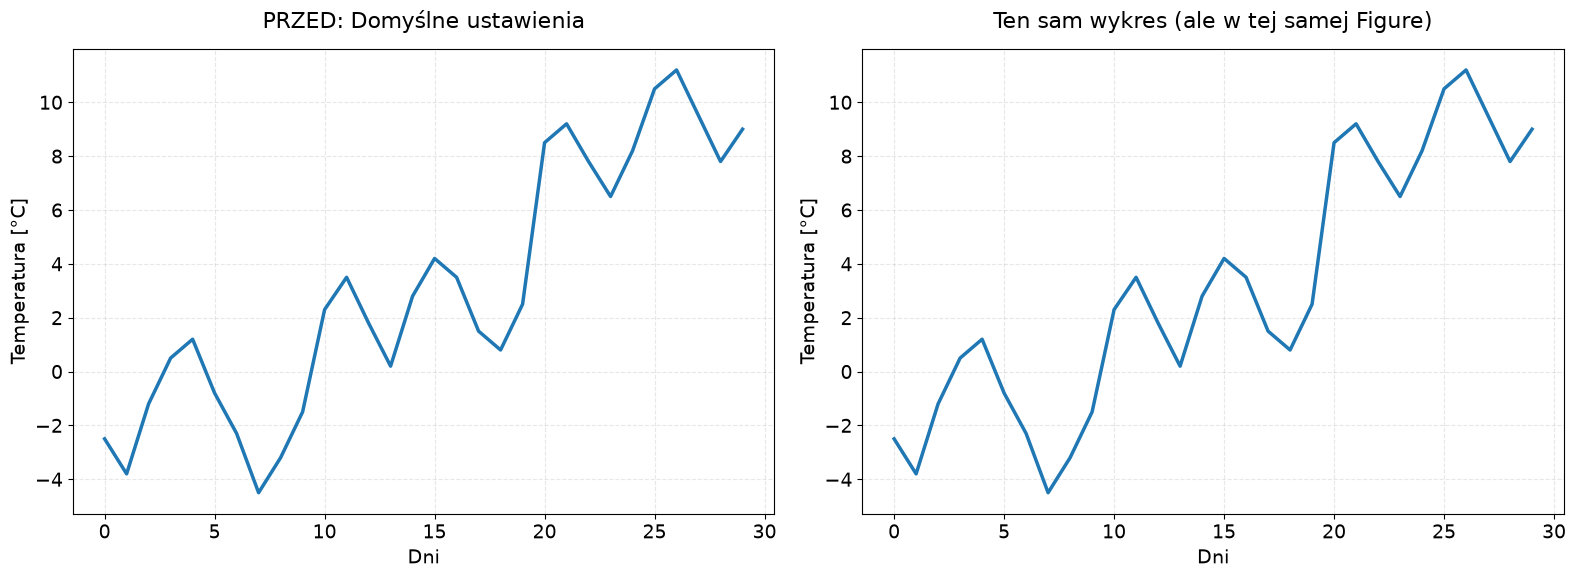


💡 UWAGA: Drugi wykres nadal wygląda tak samo,
   bo oba są w tej samej Figure utworzonej PRZED zmianą rcParams!
   Zobaczmy teraz NOWY wykres...


In [44]:
# PRZED - wykres z domyślnymi ustawieniami
print("📊 PRZED - domyślne ustawienia Matplotlib:")
print(f"   figure.figsize: {plt.rcParams['figure.figsize']}")
print(f"   font.size: {plt.rcParams['font.size']}")
print(f"   lines.linewidth: {plt.rcParams['lines.linewidth']}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Wykres 1 - domyślny
dane = df_pogoda['temperatura'].head(30)
axes[0].plot(dane.values)
axes[0].set_title('PRZED: Domyślne ustawienia', pad=15)
axes[0].set_xlabel('Dni')
axes[0].set_ylabel('Temperatura [°C]')
axes[0].grid(True, alpha=0.3)

# KONFIGURACJA GLOBALNA - teraz zmieńmy rcParams!
print("\n🔧 Zmieniamy globalne ustawienia...")
plt.rcParams['figure.figsize'] = (14, 7)   # Większe wykresy
plt.rcParams['font.size'] = 14              # Większa czcionka
plt.rcParams['lines.linewidth'] = 2.5       # Grubsze linie
plt.rcParams['axes.titlesize'] = 16         # Większy tytuł
plt.rcParams['grid.alpha'] = 0.3            # Przezroczystość siatki
plt.rcParams['grid.linestyle'] = '--'       # Styl siatki

print(f"   ✅ figure.figsize: {plt.rcParams['figure.figsize']}")
print(f"   ✅ font.size: {plt.rcParams['font.size']}")
print(f"   ✅ lines.linewidth: {plt.rcParams['lines.linewidth']}")

# Wykres 2 - taki sam kod, ale użyje NOWYCH globalnych ustawień
axes[1].plot(dane.values)
axes[1].set_title('Ten sam wykres (ale w tej samej Figure)', pad=15)
axes[1].set_xlabel('Dni')
axes[1].set_ylabel('Temperatura [°C]')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\n💡 UWAGA: Drugi wykres nadal wygląda tak samo,")
print("   bo oba są w tej samej Figure utworzonej PRZED zmianą rcParams!")
print("   Zobaczmy teraz NOWY wykres...")

📊 PO - NOWY wykres z globalnymi ustawieniami:


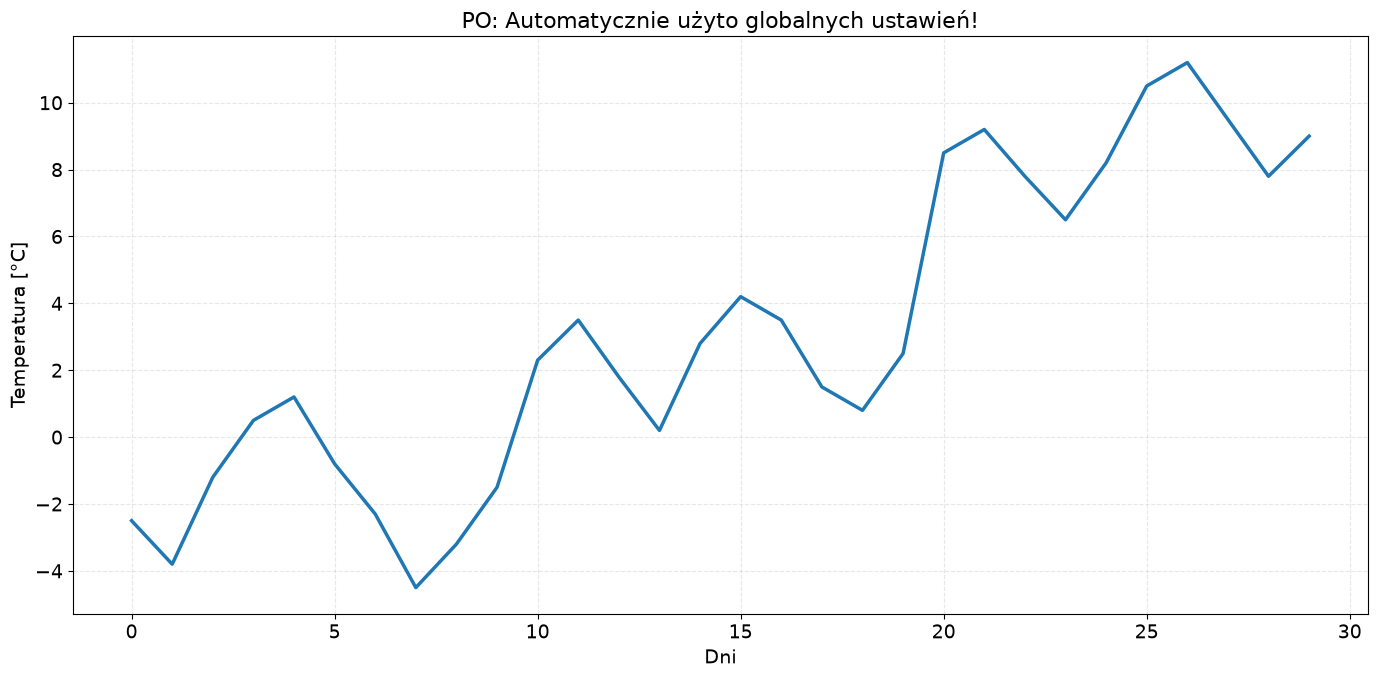


✨ Ten wykres jest:
   - Większy (14×7 zamiast domyślnych 6×4)
   - Ma większą czcionkę (14 zamiast 10)
   - Ma grubszą linię (2.5 zamiast 1.5)
   - Ma przerywaną siatkę (-- zamiast -)

💡 I to wszystko BEZ jawnego podawania tych parametrów w kodzie!


In [45]:
# PO - NOWY wykres utworzony PO zmianie rcParams - użyje nowych ustawień!
print("📊 PO - NOWY wykres z globalnymi ustawieniami:")

# Tworzymy nową Figure - ta użyje nowych rcParams!
fig, ax = plt.subplots()  # NIE podajemy figsize - użyje globalnego (14, 7)!

dane = df_pogoda['temperatura'].head(30)
ax.plot(dane.values)  # NIE podajemy linewidth - użyje globalnego (2.5)!
ax.set_title('PO: Automatycznie użyto globalnych ustawień!')  # Większa czcionka z rcParams!
ax.set_xlabel('Dni')
ax.set_ylabel('Temperatura [°C]')
ax.grid(True)  # Użyje globalnych grid settings!

plt.tight_layout()
plt.show()

print("\n✨ Ten wykres jest:")
print("   - Większy (14×7 zamiast domyślnych 6×4)")
print("   - Ma większą czcionkę (14 zamiast 10)")
print("   - Ma grubszą linię (2.5 zamiast 1.5)")
print("   - Ma przerywaną siatkę (-- zamiast -)")
print("\n💡 I to wszystko BEZ jawnego podawania tych parametrów w kodzie!")

#### Przykład 2: Dwa sposoby konfiguracji - `plt.rc()` vs `plt.rcParams[]`

Matplotlib oferuje dwa sposoby zmiany globalnych ustawień. Zobaczmy różnicę:

In [46]:
# SPOSÓB 1: plt.rcParams[] - jawny, pojedyncze parametry
print("🔧 SPOSÓB 1: plt.rcParams[] - zmiana pojedynczych parametrów")
print("="*60)

# Każdy parametr osobno
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['lines.linewidth'] = 2.0
plt.rcParams['axes.grid'] = True

print("✅ Ustawiono:")
print(f"   font.size = {plt.rcParams['font.size']}")
print(f"   font.family = {plt.rcParams['font.family']}")
print(f"   font.weight = {plt.rcParams['font.weight']}")
print(f"   figure.figsize = {plt.rcParams['figure.figsize']}")
print(f"   lines.linewidth = {plt.rcParams['lines.linewidth']}")
print(f"   axes.grid = {plt.rcParams['axes.grid']}")

print("\n" + "="*60)
print("\n🔧 SPOSÓB 2: plt.rc() - zmiana wielu parametrów z grupy")
print("="*60)

# Ta sama konfiguracja, ale krócej - grupujemy parametry
plt.rc('font', size=12, family='serif', weight='bold')
plt.rc('figure', figsize=(12, 6))
plt.rc('lines', linewidth=2.0)
plt.rc('axes', grid=True)

print("✅ Ustawiono te same wartości, ale w 4 liniach zamiast 6!")
print("\n💡 Który sposób wybrać?")
print("   - rcParams[]: gdy zmieniasz 1-2 parametry")
print("   - rc(): gdy zmieniasz wiele parametrów z tej samej grupy")
print("\n🎯 Najczęstszy wzorzec:")
print("   plt.rc('font', size=14, family='serif')")
print("   plt.rc('figure', figsize=(14, 7))")
print("   plt.rc('lines', linewidth=2.5)")

🔧 SPOSÓB 1: plt.rcParams[] - zmiana pojedynczych parametrów
✅ Ustawiono:
   font.size = 12.0
   font.family = ['serif']
   font.weight = bold
   figure.figsize = [12.0, 6.0]
   lines.linewidth = 2.0
   axes.grid = True


🔧 SPOSÓB 2: plt.rc() - zmiana wielu parametrów z grupy
✅ Ustawiono te same wartości, ale w 4 liniach zamiast 6!

💡 Który sposób wybrać?
   - rcParams[]: gdy zmieniasz 1-2 parametry
   - rc(): gdy zmieniasz wiele parametrów z tej samej grupy

🎯 Najczęstszy wzorzec:
   plt.rc('font', size=14, family='serif')
   plt.rc('figure', figsize=(14, 7))
   plt.rc('lines', linewidth=2.5)


#### Przykład 3: Praktyczna konfiguracja dla raportu

Stwórzmy gotową konfigurację dla **profesjonalnego raportu** - taka którą możesz skopiować na początek swojego projektu:

🎨 Ustawiam profesjonalną konfigurację dla raportu...
✅ Konfiguracja zastosowana!

📋 Wszystkie kolejne wykresy będą miały:
   • Rozmiar: 14×7 cali
   • Czcionkę: 13px (tytuły 16px)
   • Grubość linii: 2.5
   • Siatkę: automatycznie włączoną
   • Profesjonalną paletę kolorów


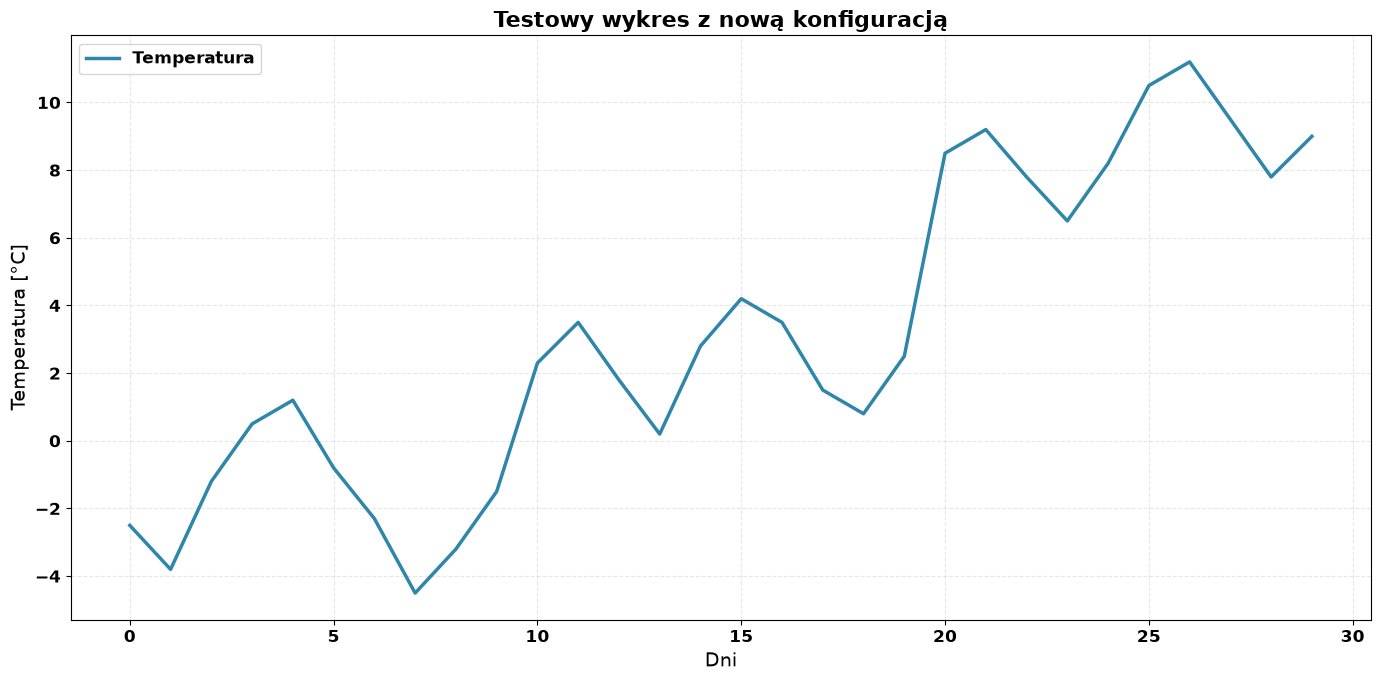


💡 Możesz to skopiować i wkleić na początek każdego notebooka/skryptu!


In [47]:
# ==========================================
# 🎨 KONFIGURACJA GLOBALNA DLA RAPORTU
# Skopiuj na początek swojego projektu!
# ==========================================

print("🎨 Ustawiam profesjonalną konfigurację dla raportu...")

# 1. Rozmiar i jakość wykresów
plt.rc('figure', figsize=(14, 7), dpi=100)

# 2. Czcionki - większe i czytelniejsze
plt.rc('font', size=13, family='sans-serif')
plt.rc('axes', titlesize=16, labelsize=14, titleweight='bold')
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
plt.rc('legend', fontsize=12)

# 3. Linie - grubsze i wyraźniejsze
plt.rc('lines', linewidth=2.5, markersize=8)

# 4. Siatka - subtelna ale widoczna
plt.rc('grid', alpha=0.3, linestyle='--', linewidth=0.8)
plt.rc('axes', grid=True)  # Automatycznie włącz siatkę

# 5. Kolory - profesjonalna paleta
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[
    '#2E86AB',  # Niebieski
    '#A23B72',  # Fioletowy
    '#F18F01',  # Pomarańczowy
    '#C73E1D',  # Czerwony
    '#6A994E',  # Zielony
])

print("✅ Konfiguracja zastosowana!")
print("\n📋 Wszystkie kolejne wykresy będą miały:")
print("   • Rozmiar: 14×7 cali")
print("   • Czcionkę: 13px (tytuły 16px)")
print("   • Grubość linii: 2.5")
print("   • Siatkę: automatycznie włączoną")
print("   • Profesjonalną paletę kolorów")

# Testowy wykres
fig, ax = plt.subplots()
dane = df_pogoda['temperatura'].head(30)
ax.plot(dane.values, label='Temperatura')
ax.set_title('Testowy wykres z nową konfiguracją')
ax.set_xlabel('Dni')
ax.set_ylabel('Temperatura [°C]')
ax.legend()
plt.tight_layout()
plt.show()

print("\n💡 Możesz to skopiować i wkleić na początek każdego notebooka/skryptu!")

**Kluczowe spostrzeżenia - rcParams (Globalna Konfiguracja):**

✅ **Kiedy używać rcParams:**
- **Projekty z wieloma wykresami** - raport z 20+ wykresami
- **Spójny styl** - chcesz żeby wszystkie wykresy wyglądały tak samo
- **Oszczędność czasu** - nie chcesz w każdym wykresie powtarzać `figsize=(14,7), fontsize=14`
- **Customizacja domyślnych wartości** - np. zawsze chcesz większą czcionkę niż 10px

❌ **Kiedy NIE używać:**
- **Pojedyncze wykresy** - jeśli robisz jeden wykres, łatwiej ustawić lokalnie
- **Różne style dla różnych wykresów** - jeśli każdy wykres ma być inny
- **Tymczasowe zmiany** - jeśli zmieniasz coś tylko dla jednego wykresu

---

📊 **Kompletny szablon - 15 najpopularniejszych parametrów:**

```python
import matplotlib.pyplot as plt

# === ROZMIAR I JAKOŚĆ ===
plt.rc('figure', 
    figsize=(14, 7),        # Rozmiar wykresu (szerokość, wysokość) w calach
    dpi=100                 # Rozdzielczość (dots per inch)
)

# === CZCIONKI ===
plt.rc('font',
    size=13,                # Domyślny rozmiar czcionki
    family='sans-serif',    # Rodzina: 'serif', 'sans-serif', 'monospace'
    weight='normal'         # Grubość: 'normal', 'bold'
)
plt.rc('axes',
    titlesize=16,           # Rozmiar tytułu wykresu
    labelsize=14,           # Rozmiar opisów osi
    titleweight='bold'      # Grubość tytułu
)
plt.rc('xtick', labelsize=12)  # Rozmiar etykiet osi X
plt.rc('ytick', labelsize=12)  # Rozmiar etykiet osi Y
plt.rc('legend', fontsize=12)  # Rozmiar czcionki w legendzie

# === LINIE ===
plt.rc('lines',
    linewidth=2.5,          # Grubość linii
    linestyle='-',          # Styl: '-', '--', ':', '-.'
    markersize=8            # Rozmiar markerów
)

# === SIATKA ===
plt.rc('grid',
    alpha=0.3,              # Przezroczystość (0=niewidoczna, 1=pełna)
    linestyle='--',         # Styl linii siatki
    linewidth=0.8,          # Grubość linii siatki
    color='gray'            # Kolor siatki
)
plt.rc('axes', grid=True)   # Automatycznie włącz siatkę na wszystkich wykresach

# === KOLORY ===
# Zmień domyślną paletę kolorów
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[
    '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E'
])
```

---

🎯 **Dwa sposoby: rc() vs rcParams[]**

**SPOSÓB 1: `plt.rc()` - grupowy (rekomendowany dla wielu parametrów)**
```python
# Zmienia wiele parametrów z tej samej grupy naraz
plt.rc('font', size=14, family='serif', weight='bold')
plt.rc('figure', figsize=(14, 7), dpi=100)
plt.rc('lines', linewidth=2.5, markersize=8)
```
✅ **Zalety:** Krótszy, czytelniejszy, grupuje związane parametry  
✅ **Użyj gdy:** Zmieniasz 2+ parametrów z tej samej grupy

**SPOSÓB 2: `plt.rcParams[]` - pojedynczy (jawny)**
```python
# Zmienia pojedyncze parametry
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.figsize'] = (14, 7)
```
✅ **Zalety:** Jawny, dokładnie wiesz co zmieniasz  
✅ **Użyj gdy:** Zmieniasz 1-2 parametry, debugujesz, sprawdzasz wartość

---

💡 **Best Practices:**

**1. Umieść konfigurację na początku notebooka/skryptu:**
```python
# Na samym początku, zaraz po import
import matplotlib.pyplot as plt
import pandas as pd

# Globalna konfiguracja
plt.rc('font', size=14)
plt.rc('figure', figsize=(14, 7))

# Teraz reszta kodu...
```

**2. Sprawdź aktualną wartość przed zmianą:**
```python
print(f"Przed: {plt.rcParams['font.size']}")  # np. 10
plt.rcParams['font.size'] = 14
print(f"Po: {plt.rcParams['font.size']}")     # 14
```

**3. Zobacz wszystkie dostępne parametry:**
```python
print(len(plt.rcParams))  # ~366 parametrów!
print(list(plt.rcParams.keys())[:10])  # Pierwsze 10
```

**4. Reset do domyślnych ustawień:**
```python
import matplotlib as mpl
mpl.rcdefaults()  # Przywraca domyślne wartości wszystkich parametrów
```

**5. Tymczasowa zmiana (tylko dla jednego wykresu):**
```python
with plt.rc_context({'font.size': 20, 'lines.linewidth': 3}):
    # Tutaj wykresy użyją tych ustawień
    fig, ax = plt.subplots()
    ax.plot(x, y)
    plt.show()

# Tutaj wróciliśmy do poprzednich ustawień
```

**6. Najpopularniejsze kombinacje (gotowce):**

```python
# Dla prezentacji (duże, czytelne)
plt.rc('font', size=16)
plt.rc('figure', figsize=(16, 9), dpi=120)
plt.rc('lines', linewidth=3)

# Dla publikacji naukowych (małe, oszczędne)
plt.rc('font', size=10, family='serif')
plt.rc('figure', figsize=(8, 6), dpi=300)
plt.rc('lines', linewidth=1.5)

# Dla dashboardów (kompaktowe, wiele wykresów)
plt.rc('font', size=11)
plt.rc('figure', figsize=(10, 5))
plt.rc('grid', alpha=0.2)
```

---

⚠️ **Częste pułapki:**

**1. Zmiana NIE działa retroaktywnie:**
```python
fig, ax = plt.subplots()  # Utworzono PRZED zmianą
plt.rcParams['font.size'] = 20  # Zmiana NIE wpłynie na powyższy wykres!

# Rozwiązanie: stwórz nowy wykres
fig2, ax2 = plt.subplots()  # Teraz użyje font.size=20 ✅
```

**2. Konflikt z lokalnymi ustawieniami:**
```python
plt.rcParams['lines.linewidth'] = 3  # Globalnie 3

fig, ax = plt.subplots()
ax.plot(x, y, linewidth=1)  # Lokalnie 1 - WYGRYWA! ✅
# Lokalne ustawienia ZAWSZE wygrywają z globalnymi
```

**3. Zapomnienie o resecie między eksperymentami:**
```python
# W Jupyter notebook - parametry się kumulują!
plt.rcParams['font.size'] = 20  # Cell 1
# ... wiele komórek później ...
# Nadal font.size = 20!

# Rozwiązanie: reset na początku
import matplotlib as mpl
mpl.rcdefaults()
```

---

🔍 **Przydatne komendy:**

```python
# Zobacz WSZYSTKIE parametry
print(plt.rcParams)

# Szukaj po nazwie (zawiera 'font')
{k: v for k, v in plt.rcParams.items() if 'font' in k}

# Zapisz aktualną konfigurację
current_config = dict(plt.rcParams)

# Przywróć zapisaną konfigurację
plt.rcParams.update(current_config)

# Zobacz domyślne wartości
import matplotlib as mpl
print(mpl.rcParamsDefault['font.size'])  # 10.0
```

---

📚 **Dokumentacja:**
- Pełna lista parametrów: https://matplotlib.org/stable/tutorials/introductory/customizing.html
- rcParams reference: https://matplotlib.org/stable/api/matplotlib_configuration_api.html

---

### 1.10 Adnotacje - `annotate` (zaawansowane)

Wcześniej poznaliśmy podstawy adnotacji (`ax.annotate()`). Teraz zobaczmy **zaawansowane techniki** - różne systemy współrzędnych, style strzałek i stylowanie ramek.

#### Historia z prezentacji dla zarządu

Szef poprosił Cię o wykres sprzedaży:

> "Potrzebuję wykresu z **wyraźnym zaznaczeniem** najlepszego miesiąca. Dodaj strzałkę, która wskazuje ten punkt i **wyraźnie wyróżnij** tę informację. To ma być prezentacja dla zarządu!"

Podstawowa adnotacja to za mało - potrzebujemy **profesjonalnego stylu**!

---

#### Kluczowe parametry zaawansowanych adnotacji:

**1. Coordinate systems (`xycoords`, `textcoords`):**
- `'data'` - współrzędne danych (domyślne) - punkt na wykresie
- `'axes fraction'` - procent osi (0,0 = lewy dolny róg, 1,1 = prawy górny)
- `'figure fraction'` - procent całego figure
- `'offset points'` - przesunięcie w punktach od `xy`

**2. Strzałki (`arrowprops`):**
- `arrowstyle` - styl strzałki: `'->'`, `'<-'`, `'<->'`, `'-['`, `'fancy'`, `'wedge'`
- `connectionstyle` - styl połączenia: `'arc3'`, `'angle'`, `'arc'`, `'bar'`
- `color`, `lw`, `alpha` - kolor, grubość, przezroczystość

**3. Ramki (`bbox`):**
- `boxstyle` - styl ramki: `'round'`, `'square'`, `'circle'`, `'larrow'`, `'rarrow'`
- `facecolor` (lub `fc`) - kolor tła
- `edgecolor` (lub `ec`) - kolor obramowania
- `alpha` - przezroczystość
- `pad` - padding wewnętrzny

---

#### Przykład 1: Różne systemy współrzędnych (`xycoords`, `textcoords`)

System współrzędnych określa, **gdzie umieścić** adnotację. Możemy mieszać różne systemy dla punktu (`xy`) i tekstu (`xytext`).

Zobaczmy 4 różne sposoby pozycjonowania:

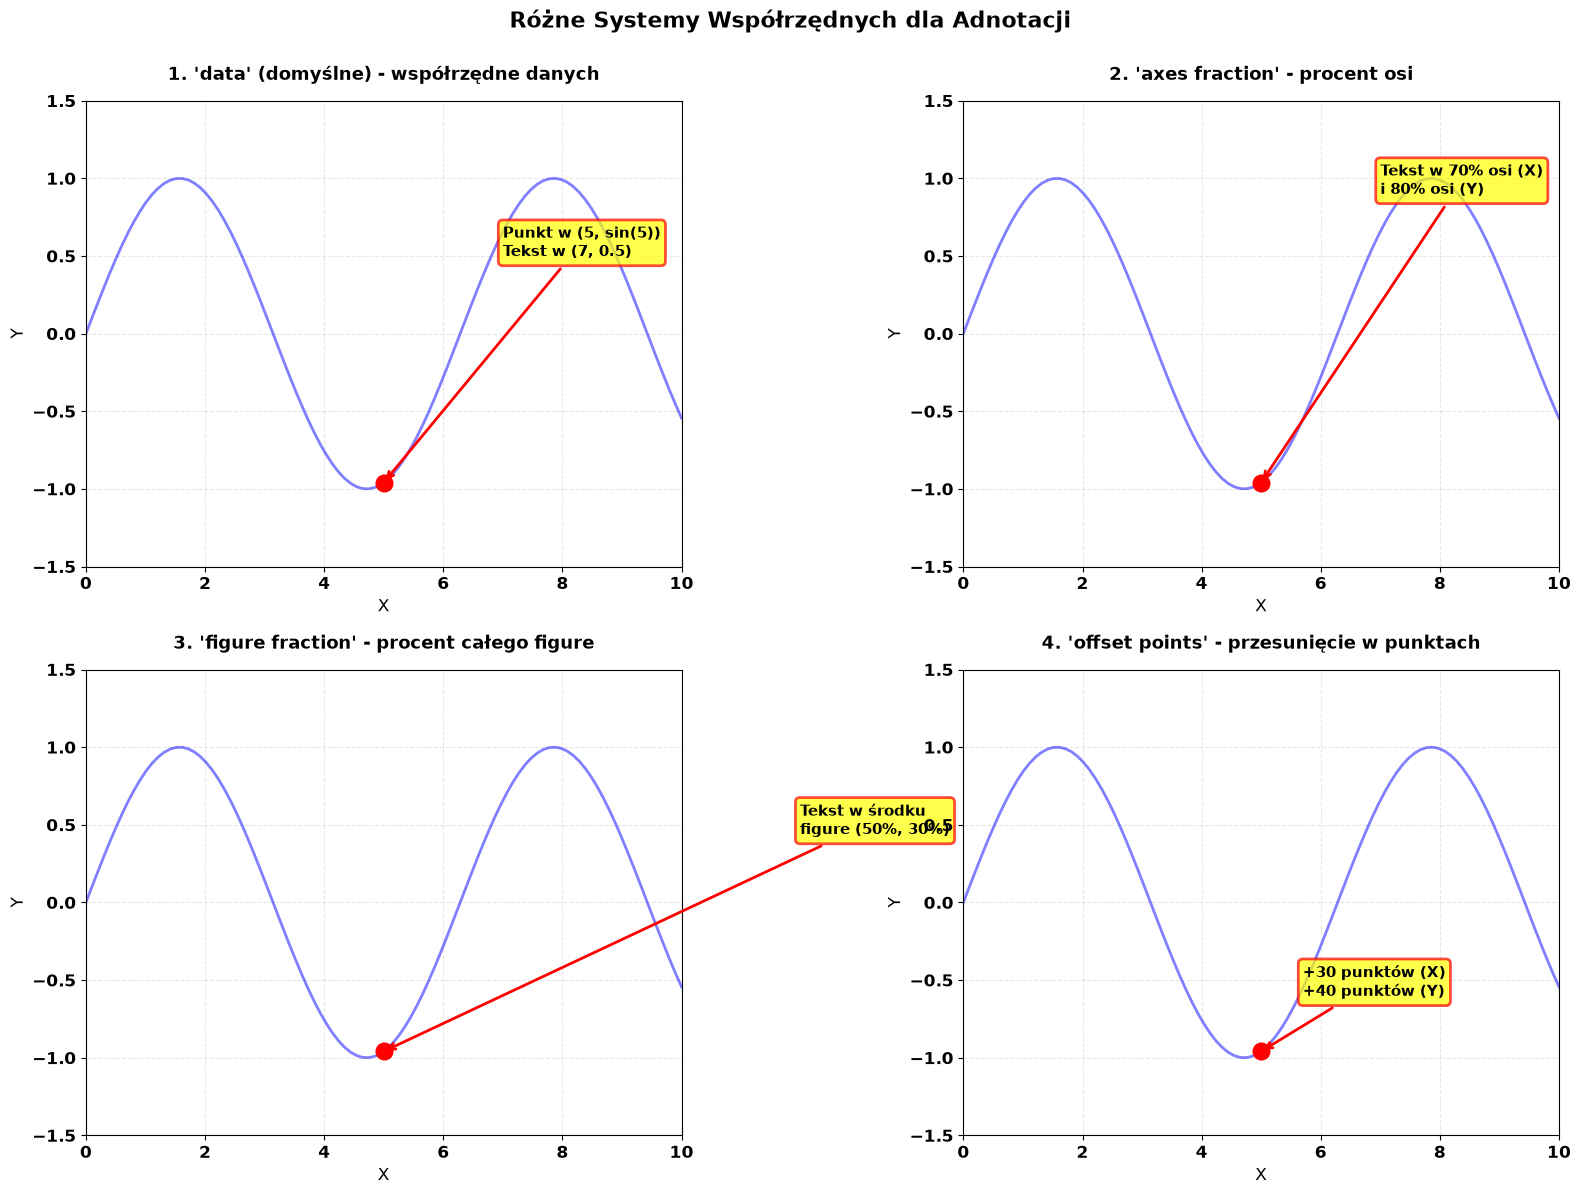

📌 Kluczowe różnice:
   1. 'data' - używa rzeczywistych wartości x, y z wykresu
   2. 'axes fraction' - (0,0)=lewy dolny róg osi, (1,1)=prawy górny
   3. 'figure fraction' - pozycja względem całego figure'a
   4. 'offset points' - przesunięcie o N punktów od xy (1 punkt ≈ 1/72 cala)

💡 Najczęściej: 'data' dla xy (punkt danych), 'offset points' dla xytext (tekst blisko punktu)


In [48]:
# Przykład z różnymi coordinate systems
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

# Przygotuj dane
x = np.linspace(0, 10, 100)
y = np.sin(x)

titles = [
    "1. 'data' (domyślne) - współrzędne danych",
    "2. 'axes fraction' - procent osi",
    "3. 'figure fraction' - procent całego figure",
    "4. 'offset points' - przesunięcie w punktach"
]

configs = [
    # 1. Data coordinates (domyślne)
    {
        'xy': (5, np.sin(5)),
        'xytext': (7, 0.5),
        'xycoords': 'data',  # Punkt na wykresie (wartości x, y)
        'textcoords': 'data',  # Tekst też w wartościach x, y
        'label': 'Punkt w (5, sin(5))\nTekst w (7, 0.5)'
    },
    # 2. Axes fraction
    {
        'xy': (5, np.sin(5)),
        'xytext': (0.7, 0.8),  # 70% szerokości, 80% wysokości osi
        'xycoords': 'data',
        'textcoords': 'axes fraction',  # Tekst jako procent osi!
        'label': 'Tekst w 70% osi (X)\ni 80% osi (Y)'
    },
    # 3. Figure fraction
    {
        'xy': (5, np.sin(5)),
        'xytext': (0.5, 0.3),  # Środek figure'a w poziomie, 30% w pionie
        'xycoords': 'data',
        'textcoords': 'figure fraction',  # Tekst względem całego figure!
        'label': 'Tekst w środku\nfigure (50%, 30%)'
    },
    # 4. Offset points
    {
        'xy': (5, np.sin(5)),
        'xytext': (30, 40),  # 30 punktów w prawo, 40 w górę od xy
        'xycoords': 'data',
        'textcoords': 'offset points',  # Przesunięcie w punktach!
        'label': '+30 punktów (X)\n+40 punktów (Y)'
    }
]

for i, (ax, title, config) in enumerate(zip(axes, titles, configs)):
    # Wykres bazowy
    ax.plot(x, y, 'b-', linewidth=2, alpha=0.5)
    
    # Zaznacz punkt
    ax.plot(config['xy'][0], config['xy'][1], 'ro', markersize=12, zorder=5)
    
    # Adnotacja z danym coordinate system
    ax.annotate(
        config['label'],
        xy=config['xy'],
        xytext=config['xytext'],
        xycoords=config['xycoords'],
        textcoords=config['textcoords'],
        arrowprops=dict(arrowstyle='->', lw=2, color='red'),
        fontsize=11,
        fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7, edgecolor='red', linewidth=2)
    )
    
    # Stylizacja
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 10)
    ax.set_ylim(-1.5, 1.5)

plt.suptitle('Różne Systemy Współrzędnych dla Adnotacji', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("📌 Kluczowe różnice:")
print("   1. 'data' - używa rzeczywistych wartości x, y z wykresu")
print("   2. 'axes fraction' - (0,0)=lewy dolny róg osi, (1,1)=prawy górny")
print("   3. 'figure fraction' - pozycja względem całego figure'a")
print("   4. 'offset points' - przesunięcie o N punktów od xy (1 punkt ≈ 1/72 cala)")
print("\n💡 Najczęściej: 'data' dla xy (punkt danych), 'offset points' dla xytext (tekst blisko punktu)")

#### Przykład 2: Style strzałek (`arrowprops`)

Parametr `arrowprops` kontroluje **wygląd strzałki** łączącej tekst z punktem. 

**Kluczowe parametry:**
- `arrowstyle` - kształt strzałki: `'->'`, `'<-'`, `'<->'`, `'-['`, `'fancy'`, `'wedge'`, `'simple'`
- `connectionstyle` - sposób rysowania połączenia: `'arc3,rad=.3'`, `'angle,angleA=0,angleB=90'`, `'bar'`
- `color`, `lw` (linewidth), `alpha` - kolor, grubość, przezroczystość

Porównajmy różne style:

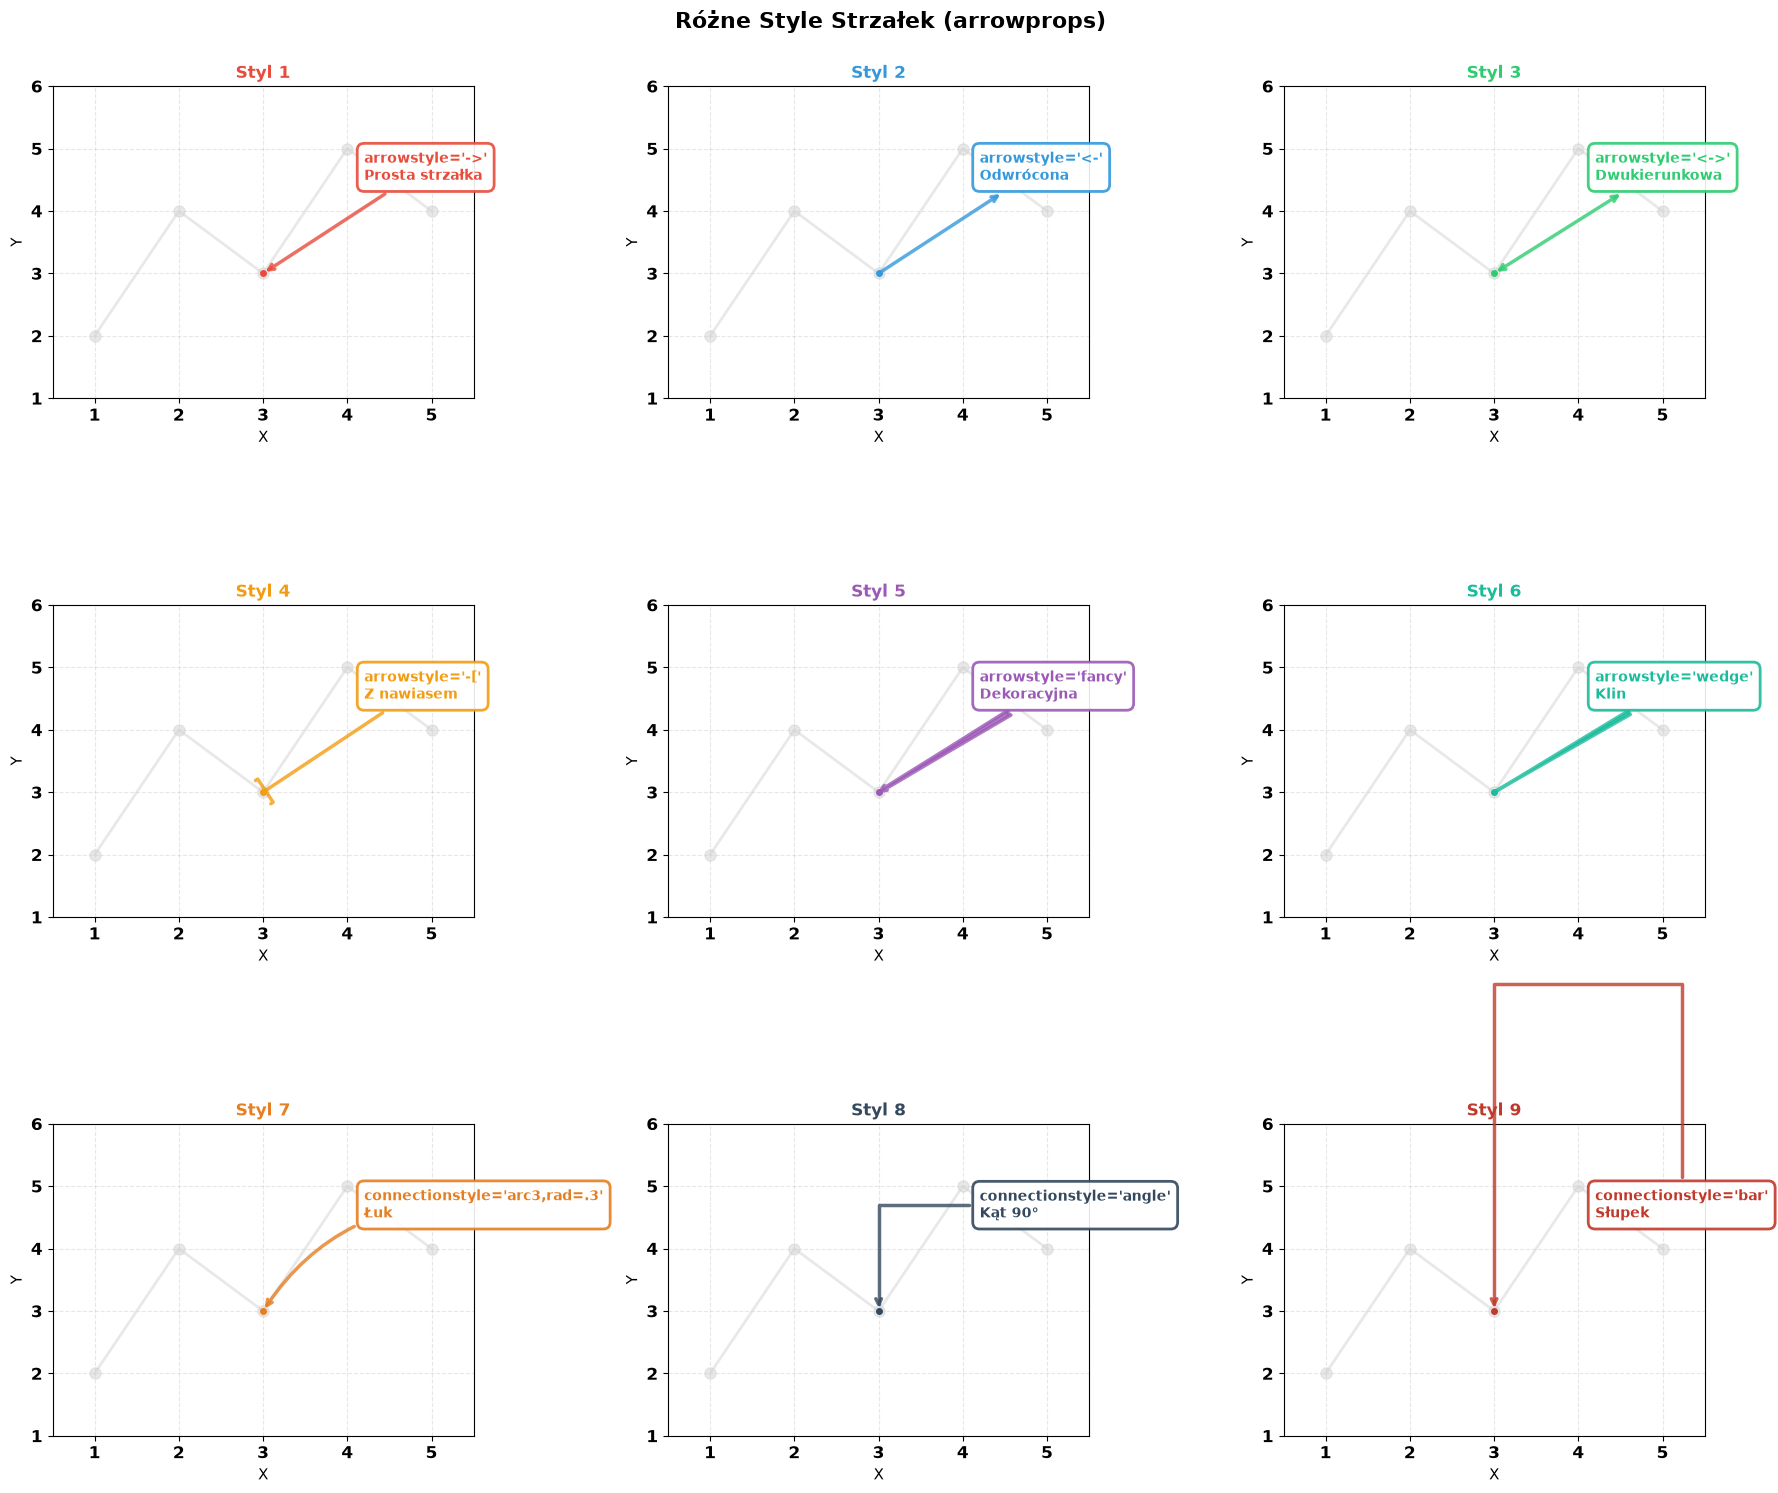

🎨 Popularne style strzałek:
   -> : Prosta strzałka (najczęściej używana)
   fancy: Dekoracyjna strzałka (ładna, ale większa)
   wedge: Klinowa strzałka (dobra dla prezentacji)

🔗 Connection styles:
   arc3,rad=.3: Łuk (rad kontroluje krzywizn ę)
   angle: Kąt pod określonym kątem (angleA, angleB)
   bar: Poprzeczka (armA, armB to długości ramion)

💡 Tip: Dla większości przypadków wystarczy: arrowstyle='->', connectionstyle='arc3'


In [51]:
# Porównanie różnych stylów strzałek
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

# Dane bazowe
x = [1, 2, 3, 4, 5]
y = [2, 4, 3, 5, 4]

# Różne konfiguracje strzałek
arrow_configs = [
    {'arrowstyle': '->', 'connectionstyle': 'arc3', 'label': "arrowstyle='->'\nProsta strzałka"},
    {'arrowstyle': '<-', 'connectionstyle': 'arc3', 'label': "arrowstyle='<-'\nOdwrócona"},
    {'arrowstyle': '<->', 'connectionstyle': 'arc3', 'label': "arrowstyle='<->'\nDwukierunkowa"},
    {'arrowstyle': '-[', 'connectionstyle': 'arc3', 'label': "arrowstyle='-['\nZ nawiasem"},
    {'arrowstyle': 'fancy', 'connectionstyle': 'arc3', 'label': "arrowstyle='fancy'\nDekoracyjna"},
    {'arrowstyle': 'wedge', 'connectionstyle': 'arc3', 'label': "arrowstyle='wedge'\nKlin"},
    {'arrowstyle': '->', 'connectionstyle': 'arc3,rad=.3', 'label': "connectionstyle='arc3,rad=.3'\nŁuk"},
    {'arrowstyle': '->', 'connectionstyle': 'angle,angleA=0,angleB=90', 'label': "connectionstyle='angle'\nKąt 90°"},
    {'arrowstyle': '->', 'connectionstyle': 'bar,armA=50,armB=50,angle=0', 'label': "connectionstyle='bar'\nSłupek"},
]

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e', '#c0392b']

for i, (ax, config, color) in enumerate(zip(axes, arrow_configs, colors)):
    # Wykres bazowy
    ax.plot(x, y, 'o-', color='lightgray', markersize=8, linewidth=2, alpha=0.5)
    
    # Zaznacz punkt do adnotacji
    ax.plot(3, 3, 'o', color=color, markersize=4, zorder=5)
    
    # Adnotacja z danym stylem strzałki
    ax.annotate(
        config['label'],
        xy=(3, 3),
        xytext=(4.2, 4.5),
        fontsize=10,
        fontweight='bold',
        color=color,
        arrowprops=dict(
            arrowstyle=config['arrowstyle'],
            connectionstyle=config['connectionstyle'],
            color=color,
            lw=2.5,
            alpha=0.8
        ),
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=color, linewidth=2, alpha=0.9)
    )
    
    # Stylizacja
    ax.set_xlim(0.5, 5.5)
    ax.set_ylim(1, 6)
    ax.set_xlabel('X', fontsize=11)
    ax.set_ylabel('Y', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Styl {i+1}', fontsize=12, fontweight='bold', color=color)

plt.suptitle('Różne Style Strzałek (arrowprops)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("🎨 Popularne style strzałek:")
print("   -> : Prosta strzałka (najczęściej używana)")
print("   fancy: Dekoracyjna strzałka (ładna, ale większa)")
print("   wedge: Klinowa strzałka (dobra dla prezentacji)")
print("\n🔗 Connection styles:")
print("   arc3,rad=.3: Łuk (rad kontroluje krzywizn ę)")
print("   angle: Kąt pod określonym kątem (angleA, angleB)")
print("   bar: Poprzeczka (armA, armB to długości ramion)")
print("\n💡 Tip: Dla większości przypadków wystarczy: arrowstyle='->', connectionstyle='arc3'")

#### Przykład 3: Style ramek (`bbox`)

Parametr `bbox` kontroluje **ramkę wokół tekstu** adnotacji. To świetny sposób na wyróżnienie ważnych informacji!

**Kluczowe parametry:**
- `boxstyle` - kształt: `'round'`, `'square'`, `'circle'`, `'larrow'`, `'rarrow'`, `'round4'`, `'sawtooth'`
- `facecolor` (lub `fc`) - kolor wypełnienia
- `edgecolor` (lub `ec`) - kolor obramowania
- `linewidth` (lub `lw`) - grubość obramowania
- `alpha` - przezroczystość (0=przezroczyste, 1=nieprzezroczyste)
- `pad` - padding (odstęp wewnętrzny)

Zobaczmy galerię różnych stylów:

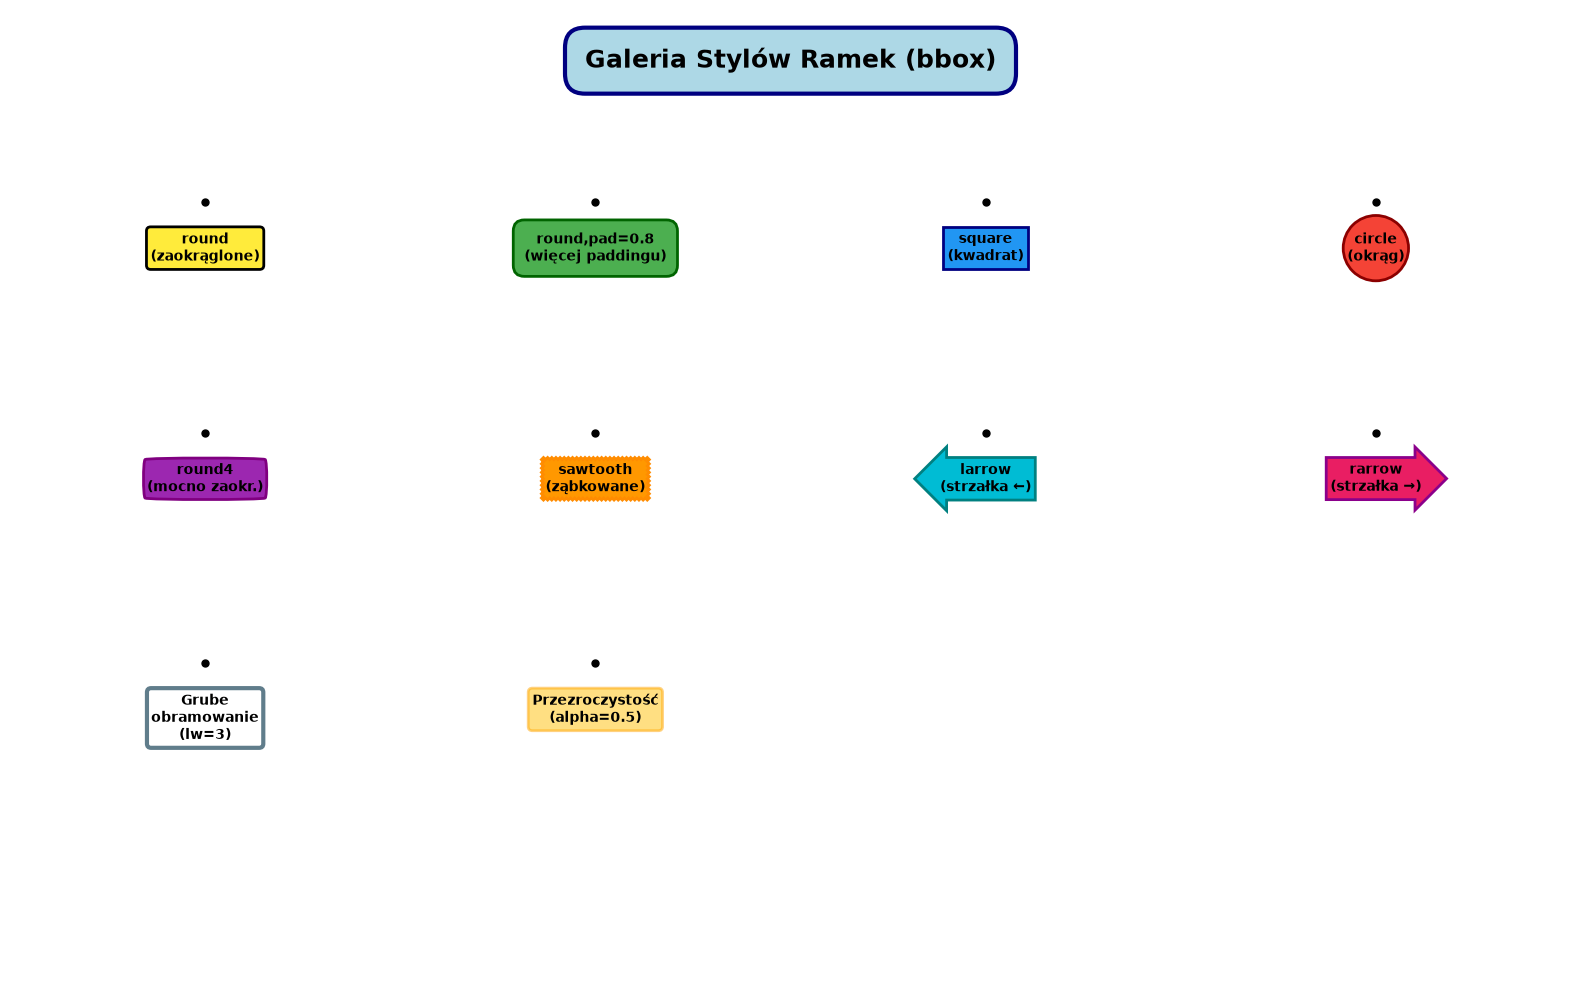

📦 Popularne boxstyles:
   round: Zaokrąglone rogi (najczęściej używane) ✅
   square: Ostre rogi (formalne dokumenty)
   larrow/rarrow: Strzałki (dla wskazań kierunku)

🎨 Kolory i style:
   fc='yellow': Żółte tło (dobre dla ostrzeżeń)
   fc='lightgreen': Zielone tło (dla sukcesów)
   fc='white', ec='red', lw=3: Białe tło, czerwona ramka (uwaga!)
   alpha=0.5: Półprzezroczyste (subtelne wyróżnienie)

💡 Tip: Użyj fc='white' z kolorowym ec dla eleganckich adnotacji!


In [52]:
# Galeria różnych stylów bbox
fig, ax = plt.subplots(figsize=(16, 10))

# Pusty wykres jako canvas
ax.set_xlim(0, 4)
ax.set_ylim(0, 5)
ax.axis('off')

# Różne konfiguracje bbox
bbox_configs = [
    {'boxstyle': 'round', 'fc': '#ffeb3b', 'ec': 'black', 'label': 'round\n(zaokrąglone)'},
    {'boxstyle': 'round,pad=0.8', 'fc': '#4caf50', 'ec': 'darkgreen', 'label': 'round,pad=0.8\n(więcej paddingu)'},
    {'boxstyle': 'square', 'fc': '#2196f3', 'ec': 'navy', 'label': 'square\n(kwadrat)'},
    {'boxstyle': 'circle', 'fc': '#f44336', 'ec': 'darkred', 'label': 'circle\n(okrąg)'},
    {'boxstyle': 'round4', 'fc': '#9c27b0', 'ec': 'purple', 'label': 'round4\n(mocno zaokr.)'},
    {'boxstyle': 'sawtooth', 'fc': '#ff9800', 'ec': 'darkorange', 'label': 'sawtooth\n(ząbkowane)'},
    {'boxstyle': 'larrow', 'fc': '#00bcd4', 'ec': 'teal', 'label': 'larrow\n(strzałka ←)'},
    {'boxstyle': 'rarrow', 'fc': '#e91e63', 'ec': 'darkmagenta', 'label': 'rarrow\n(strzałka →)'},
    {'boxstyle': 'round', 'fc': 'white', 'ec': '#607d8b', 'lw': 3, 'label': 'Grube\nobramowanie\n(lw=3)'},
    {'boxstyle': 'round', 'fc': '#ffc107', 'ec': 'orange', 'alpha': 0.5, 'label': 'Przezroczystość\n(alpha=0.5)'},
]

# Rozmieść bbox na siatce
positions = [
    (0.5, 4), (1.5, 4), (2.5, 4), (3.5, 4),
    (0.5, 2.8), (1.5, 2.8), (2.5, 2.8), (3.5, 2.8),
    (0.5, 1.6), (1.5, 1.6)
]

for (x, y), config in zip(positions, bbox_configs):
    # Punkt (mały, żeby nie przeszkadzał)
    ax.plot(x, y, 'ko', markersize=5, zorder=1)
    
    # Adnotacja z danym stylem bbox
    bbox_params = {
        'boxstyle': config['boxstyle'],
        'facecolor': config['fc'],
        'edgecolor': config['ec'],
        'linewidth': config.get('lw', 2)
    }
    
    if 'alpha' in config:
        bbox_params['alpha'] = config['alpha']
    
    ax.annotate(
        config['label'],
        xy=(x, y),
        xytext=(x, y - 0.15),
        fontsize=10,
        fontweight='bold',
        ha='center',
        va='top',
        bbox=bbox_params
    )

# Tytuł
ax.text(2, 4.7, 'Galeria Stylów Ramek (bbox)', 
        fontsize=18, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='lightblue', edgecolor='navy', linewidth=3))

plt.tight_layout()
plt.show()

print("📦 Popularne boxstyles:")
print("   round: Zaokrąglone rogi (najczęściej używane) ✅")
print("   square: Ostre rogi (formalne dokumenty)")
print("   larrow/rarrow: Strzałki (dla wskazań kierunku)")
print("\n🎨 Kolory i style:")
print("   fc='yellow': Żółte tło (dobre dla ostrzeżeń)")
print("   fc='lightgreen': Zielone tło (dla sukcesów)")
print("   fc='white', ec='red', lw=3: Białe tło, czerwona ramka (uwaga!)")
print("   alpha=0.5: Półprzezroczyste (subtelne wyróżnienie)")
print("\n💡 Tip: Użyj fc='white' z kolorowym ec dla eleganckich adnotacji!")

**Kluczowe spostrzeżenia - Zaawansowane Adnotacje:**

✅ **Coordinate systems - kiedy którego używać:**
- `xycoords='data'` + `textcoords='data'` - obie pozycje w wartościach wykresu (rzadko)
- `xycoords='data'` + `textcoords='offset points'` - **NAJCZĘŚCIEJ** - punkt danych, tekst przesunięty o N punktów
- `xycoords='data'` + `textcoords='axes fraction'` - punkt danych, tekst jako % osi (dobre dla stałej pozycji tekstu)

📊 **Kompletny szablon zaawansowanej adnotacji:**
```python
ax.annotate(
    'Tekst adnotacji',
    xy=(x_punkt, y_punkt),           # Gdzie wskazuje strzałka (zwykle 'data')
    xytext=(x_tekst, y_tekst),        # Gdzie jest tekst
    xycoords='data',                  # System współrzędnych dla xy
    textcoords='offset points',       # System dla xytext (często offset points)
    
    # Strzałka
    arrowprops=dict(
        arrowstyle='->',              # Kształt strzałki
        connectionstyle='arc3,rad=.2', # Styl połączenia (łuk)
        color='red',                  # Kolor
        lw=2,                         # Grubość
        alpha=0.8                     # Przezroczystość
    ),
    
    # Ramka wokół tekstu
    bbox=dict(
        boxstyle='round,pad=0.5',     # Kształt (zaokr. + padding)
        facecolor='yellow',           # Kolor tła
        edgecolor='red',              # Kolor ramki
        linewidth=2,                  # Grubość ramki
        alpha=0.9                     # Przezroczystość
    ),
    
    # Stylizacja tekstu
    fontsize=12,
    fontweight='bold',
    color='darkred',
    ha='center',                      # Horizontal alignment
    va='bottom'                       # Vertical alignment
)
```

🎨 **Popularne kombinacje (gotowce):**

**1. Elegancka adnotacja (profesjonalna prezentacja):**
```python
bbox=dict(boxstyle='round', fc='white', ec='navy', lw=2, alpha=0.95)
arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='navy', lw=2)
```

**2. Ostrzeżenie/Uwaga (czerwone, wyraziste):**
```python
bbox=dict(boxstyle='round', fc='#ffe6e6', ec='red', lw=3)
arrowprops=dict(arrowstyle='wedge', color='red', lw=2.5)
```

**3. Sukces/Pozytywne (zielone):**
```python
bbox=dict(boxstyle='round', fc='lightgreen', ec='darkgreen', lw=2)
arrowprops=dict(arrowstyle='fancy', color='green', lw=2)
```

**4. Subtelne wyróżnienie (półprzezroczyste):**
```python
bbox=dict(boxstyle='round', fc='lightyellow', ec='gray', lw=1, alpha=0.6)
arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='gray', lw=1.5, alpha=0.7)
```

💡 **Best practices:**
- Używaj `textcoords='offset points'` dla tekstu blisko punktu (np. `xytext=(20, 30)`)
- Dla strzałek wystarczy `arrowstyle='->'` + `connectionstyle='arc3'`
- Białe tło (`fc='white'`) z kolorową ramką (`ec`) wygląda najbardziej profesjonalnie
- Nie przesadzaj z `alpha` - wartości 0.8-0.95 są najlepsze
- Zawsze testuj różne `xytext` - czasami trzeba eksperymentować z pozycją!

**4. Wyrównanie tekstu (`ha`, `va`):**
- `ha` = **horizontal alignment** (wyrównanie w poziomie)
  - `'left'` - lewy brzeg tekstu w punkcie xy
  - `'center'` - środek tekstu w punkcie xy (domyślne)
  - `'right'` - prawy brzeg tekstu w punkcie xy
- `va` = **vertical alignment** (wyrównanie w pionie)
  - `'top'` - górny brzeg tekstu w punkcie xy
  - `'center'` - środek tekstu w punkcie xy (domyślne)
  - `'bottom'` - dolny brzeg tekstu w punkcie xy
  - `'baseline'` - linia bazowa tekstu (dla wyrównania z innymi tekstami)

**Przykład:**
```python
ax.text(5, 10, 'Tekst', ha='left', va='bottom')
# Punkt (5, 10) będzie w lewym dolnym rogu tekstu
```


---
## 2. Stylowanie wykresów

Teraz nauczysz się jak kontrolować wygląd wykresów - kolory, style linii, czcionki i wiele więcej!

### 2.1 Kolory

W Matplotlib możesz określać kolory na wiele sposobów:

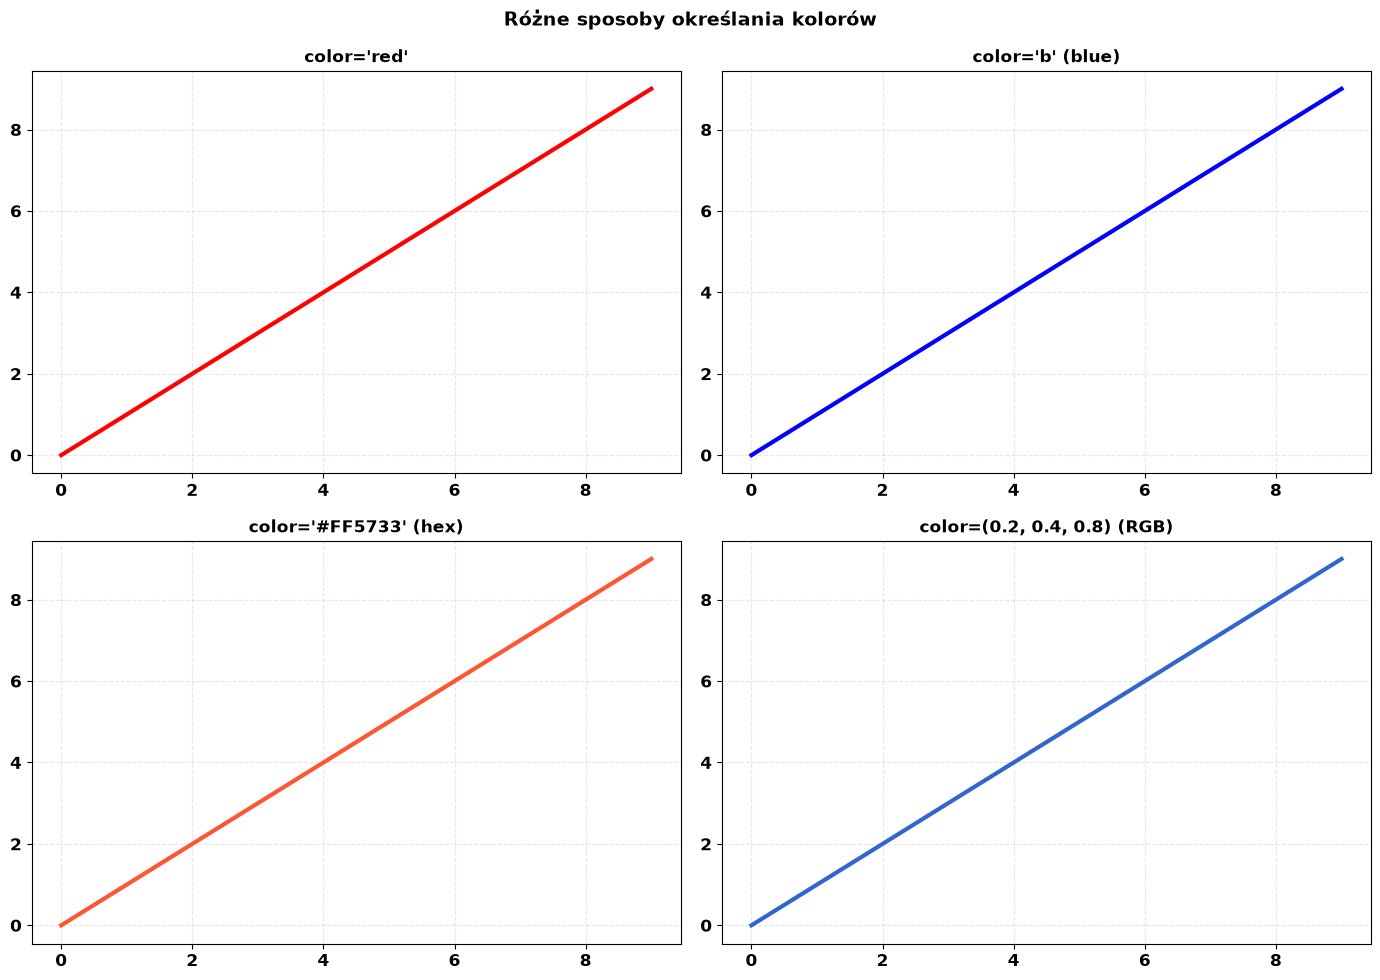

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

x = range(10)
y = range(10)

# 1. Nazwy kolorów
axes[0].plot(x, y, color='red', linewidth=3)
axes[0].set_title("color='red'", fontsize=12)

# 2. Skróty jednoliterowe
axes[1].plot(x, y, color='b', linewidth=3)  # b=blue, g=green, r=red, c=cyan, m=magenta, y=yellow, k=black, w=white
axes[1].set_title("color='b' (blue)", fontsize=12)

# 3. Hex kody
axes[2].plot(x, y, color='#FF5733', linewidth=3)
axes[2].set_title("color='#FF5733' (hex)", fontsize=12)

# 4. RGB tuple (wartości 0-1)
axes[3].plot(x, y, color=(0.2, 0.4, 0.8), linewidth=3)
axes[3].set_title("color=(0.2, 0.4, 0.8) (RGB)", fontsize=12)

plt.suptitle('Różne sposoby określania kolorów', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Popularne nazwy kolorów:**
- Podstawowe: red, green, blue, yellow, cyan, magenta, black, white
- Dodatkowe: orange, purple, pink, brown, gray, lime, navy, teal, maroon
- Odcienie: lightblue, darkgreen, lightgray, etc.

**Palety kolorów dla profesjonalnych wykresów:**

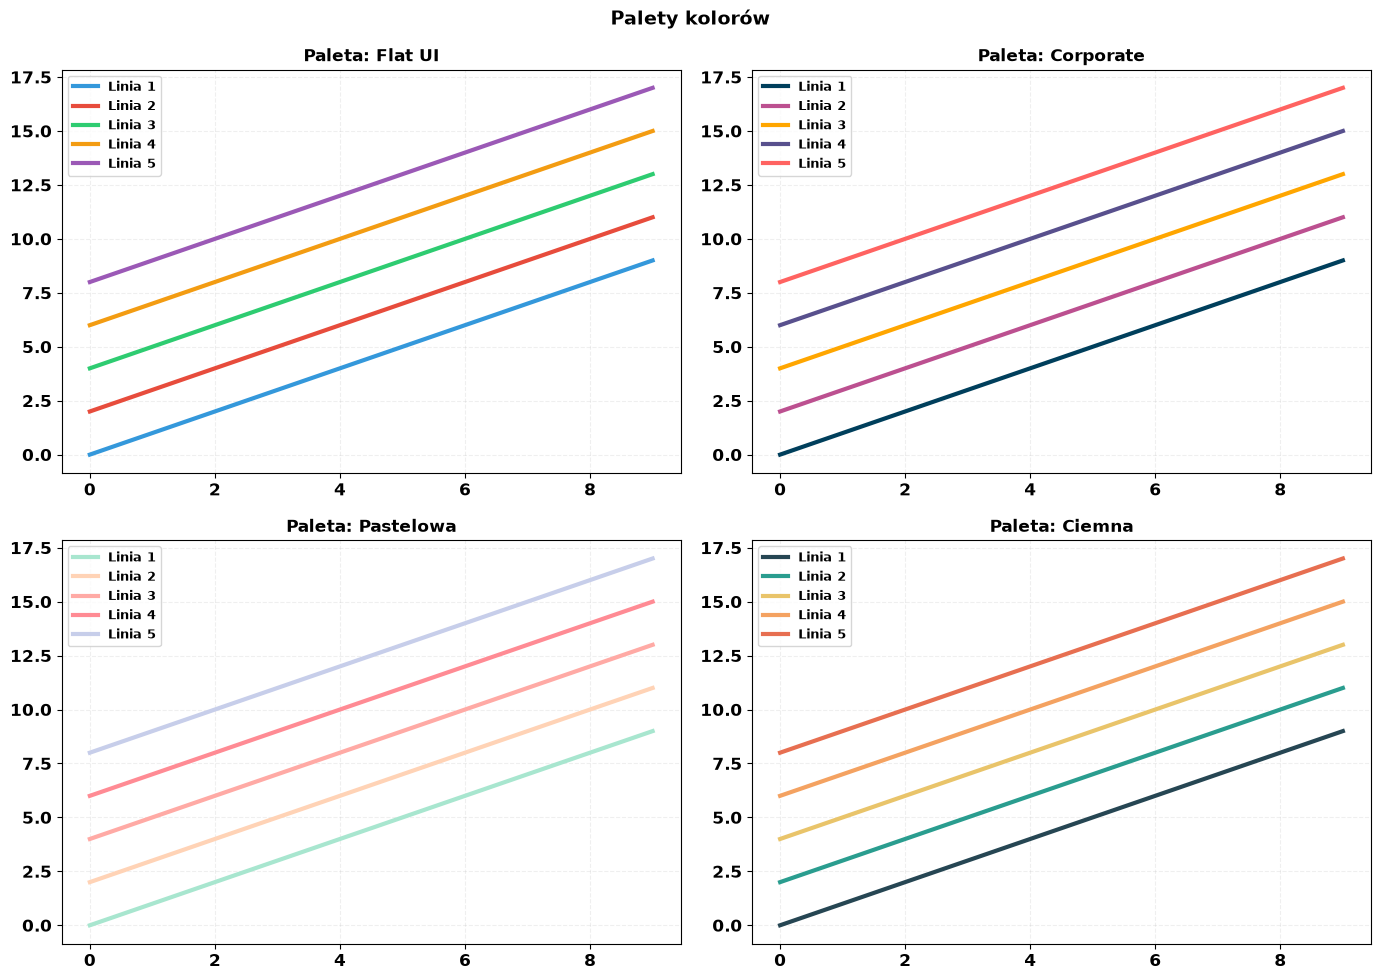

In [54]:
# Palety kolorów
palety = {
    'Flat UI': ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'],
    'Corporate': ['#003f5c', '#bc5090', '#ffa600', '#58508d', '#ff6361'],
    'Pastelowa': ['#a8e6cf', '#ffd3b6', '#ffaaa5', '#ff8b94', '#c7ceea'],
    'Ciemna': ['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

x = range(10)

for i, (nazwa, kolory) in enumerate(palety.items()):
    for j, kolor in enumerate(kolory):
        axes[i].plot(x, [k + j*2 for k in x], color=kolor, linewidth=3, label=f'Linia {j+1}')
    axes[i].set_title(f'Paleta: {nazwa}', fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.2)

plt.suptitle('Palety kolorów', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Style linii i markery

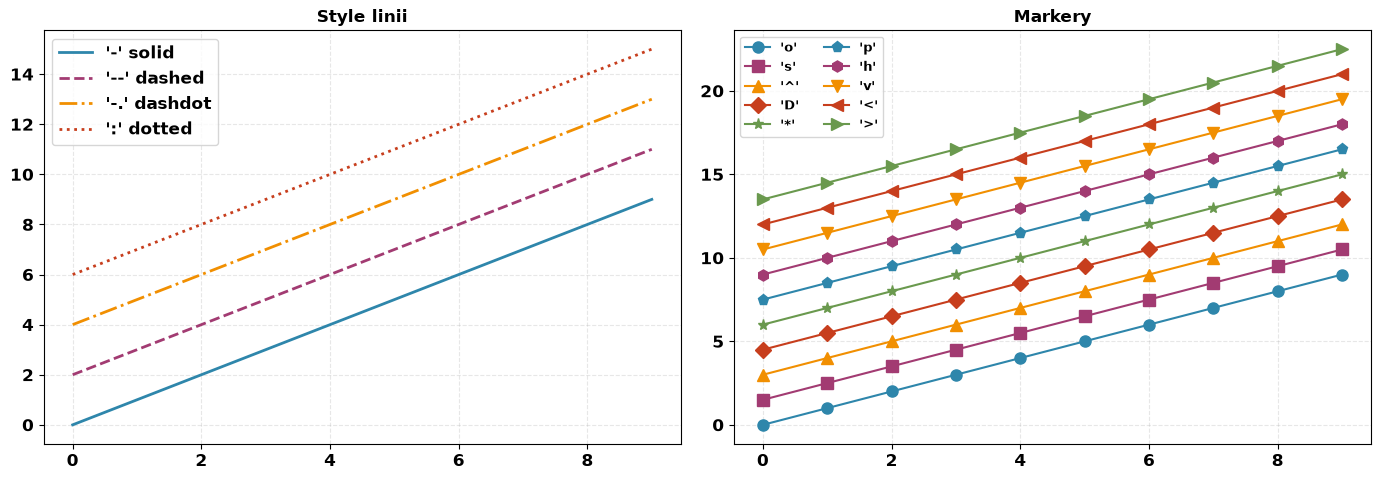

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(10)
y = range(10)

# Style linii
axes[0].plot(x, [i for i in y], linestyle='-', linewidth=2, label="'-' solid")
axes[0].plot(x, [i+2 for i in y], linestyle='--', linewidth=2, label="'--' dashed")
axes[0].plot(x, [i+4 for i in y], linestyle='-.', linewidth=2, label="'-.' dashdot")
axes[0].plot(x, [i+6 for i in y], linestyle=':', linewidth=2, label="':' dotted")
axes[0].set_title('Style linii', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Markery
markery = ['o', 's', '^', 'D', '*', 'p', 'h', 'v', '<', '>']
for i, marker in enumerate(markery):
    axes[1].plot(x, [k + i*1.5 for k in range(10)], 
                 marker=marker, markersize=8, linewidth=1.5, label=f"'{marker}'")
axes[1].set_title('Markery', fontsize=12, fontweight='bold')
axes[1].legend(ncol=2, fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Style linii:**
- `'-'` - linia ciągła (solid)
- `'--'` - linia przerywana (dashed)
- `'-.'` - linia kropka-kreska (dash-dot)
- `':'` - linia kropkowana (dotted)

**Popularne markery:**
- `'o'` - kółko
- `'s'` - kwadrat
- `'^'`, `'v'`, `'<'`, `'>'` - trójkąty
- `'D'` - diament
- `'*'` - gwiazdka
- `'+'`, `'x'` - krzyżyki

### 2.3 Czcionki

Kontroluj wygląd tekstu na wykresach:

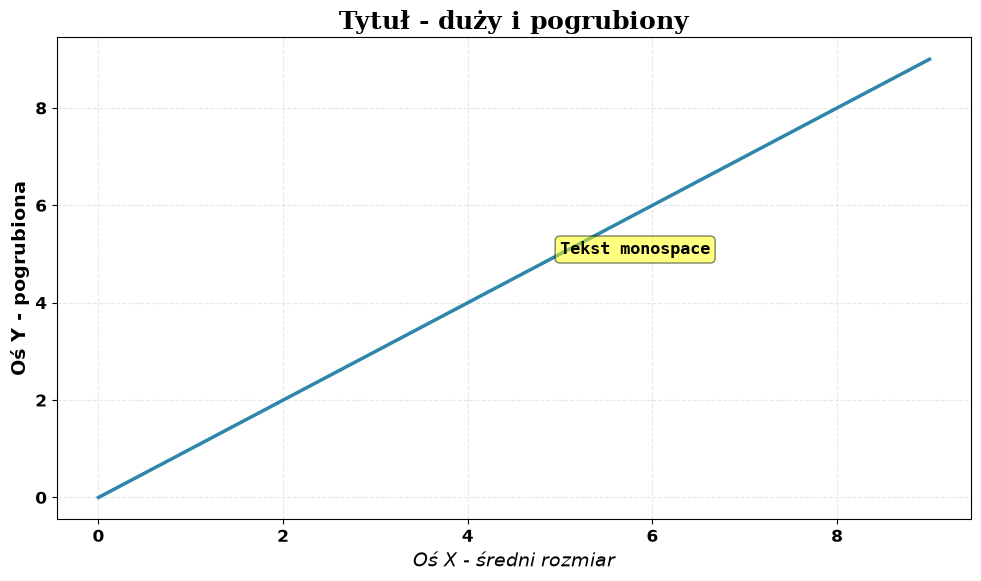

In [56]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(10), range(10))

# Różne style czcionek
ax.set_title('Tytuł - duży i pogrubiony', 
             fontsize=18, 
             fontweight='bold',
             fontfamily='serif')       # serif, sans-serif, monospace

ax.set_xlabel('Oś X - średni rozmiar', 
              fontsize=14,
              fontstyle='italic')       # normal, italic, oblique

ax.set_ylabel('Oś Y - pogrubiona', 
              fontsize=14,
              fontweight='bold')        # normal, bold, heavy, light

# Tekst na wykresie
ax.text(5, 5, 'Tekst monospace', 
        fontsize=12, 
        fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

### 2.4 Gotowe style (`plt.style.use`)

Matplotlib ma wiele gotowych stylów, które możesz zastosować jedną komendą!

In [57]:
# Zobacz dostępne style
print("Dostępne style:")
print(plt.style.available)

Dostępne style:
['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


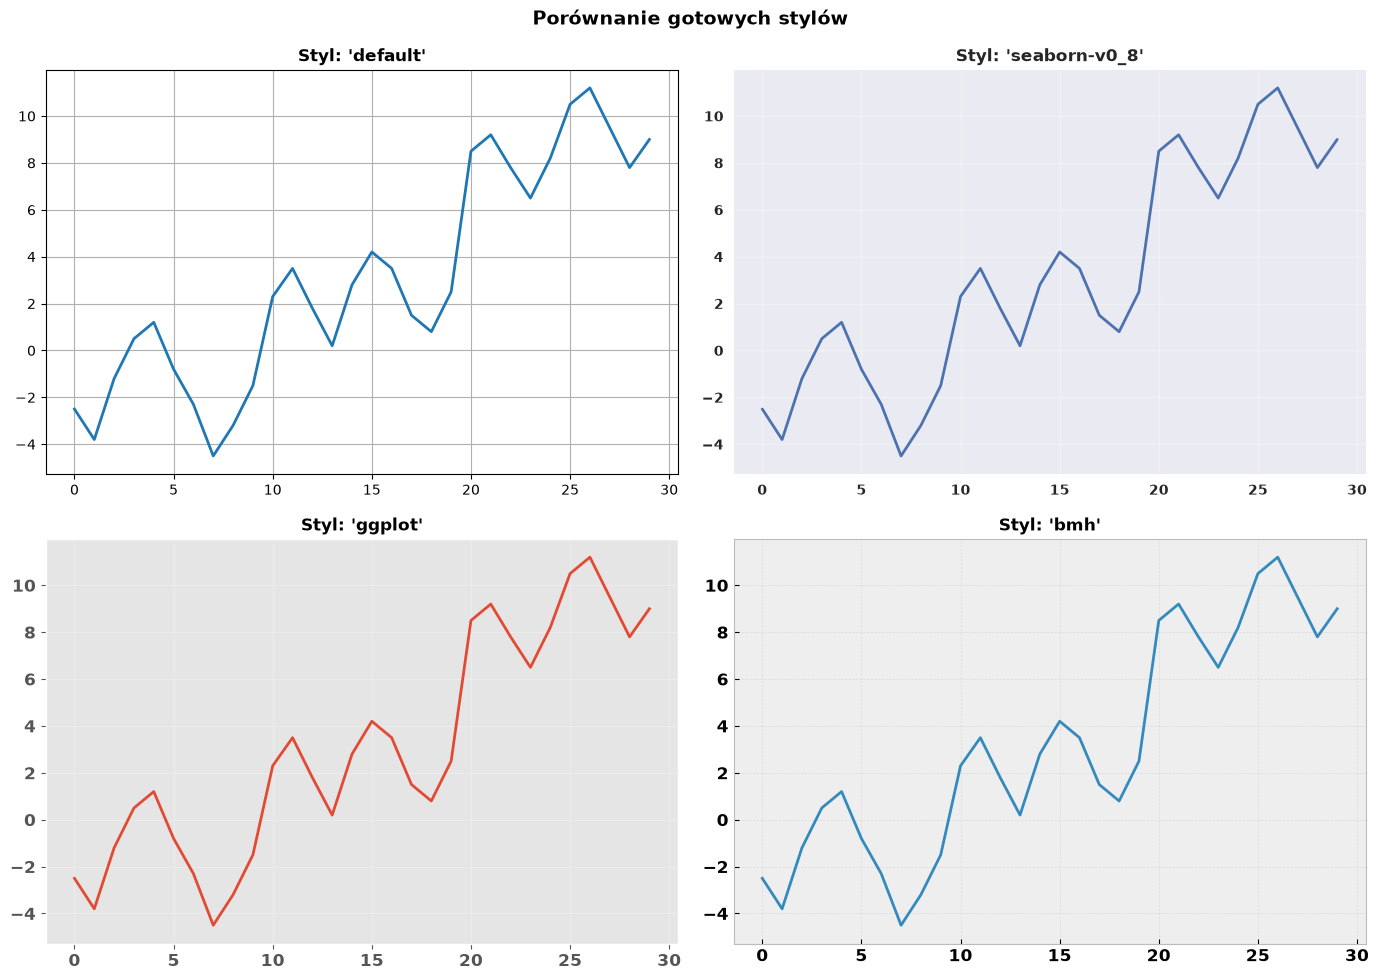


💡 Kluczowa zmiana:
   ❌ ŹLE: Tworzyć wszystkie axes PRZED pętlą (plt.subplots(2,2))
   ✅ DOBRZE: Tworzyć każdą axes WEWNĄTRZ plt.style.context()

📊 Teraz każdy wykres ma inny styl!
   - default: Klasyczny matplotlib (niebieski, białe tło)
   - seaborn-v0_8: Paleta kolorów seaborn, szare tło
   - ggplot: Inspirowany R/ggplot2, szare tło, biała siatka
   - bmh: 'Bayesian Methods for Hackers', kolorowe linie


In [59]:
# Porównanie stylów - POPRAWNIE!
# PROBLEM: plt.style.context() działa tylko na NOWO TWORZONYCH obiektach
# Trzeba tworzyć każdą subplot WEWNĄTRZ context managera!

style_names = ['default', 'seaborn-v0_8', 'ggplot', 'bmh']

fig = plt.figure(figsize=(14, 10))

for i, style in enumerate(style_names):
    with plt.style.context(style):  # Zastosuj styl
        # Teraz dopiero tworzymy subplot - zostanie stylizowany!
        ax = fig.add_subplot(2, 2, i+1)
        
        # Narysuj wykres
        dane = df_pogoda['temperatura'].head(30)
        ax.plot(dane.values, linewidth=2)
        ax.set_title(f"Styl: '{style}'", fontsize=12, fontweight='bold')
        ax.grid(True)

plt.suptitle('Porównanie gotowych stylów', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Kluczowa zmiana:")
print("   ❌ ŹLE: Tworzyć wszystkie axes PRZED pętlą (plt.subplots(2,2))")
print("   ✅ DOBRZE: Tworzyć każdą axes WEWNĄTRZ plt.style.context()")
print("\n📊 Teraz każdy wykres ma inny styl!")
print("   - default: Klasyczny matplotlib (niebieski, białe tło)")
print("   - seaborn-v0_8: Paleta kolorów seaborn, szare tło")
print("   - ggplot: Inspirowany R/ggplot2, szare tło, biała siatka")
print("   - bmh: 'Bayesian Methods for Hackers', kolorowe linie")

**Popularne style:**
- `'default'` - domyślny styl Matplotlib
- `'seaborn-v0_8'` - styl Seaborn (elegancki)
- `'ggplot'` - styl R ggplot2
- `'bmh'` - styl Bayesian Methods for Hackers
- `'fivethirtyeight'` - styl FiveThirtyEight
- `'grayscale'` - czarno-biały

**Jak używać:**
```python
plt.style.use('seaborn-v0_8')  # Ustaw globalnie
# wszystkie wykresy będą miały ten styl

# LUB użyj tymczasowo:
with plt.style.context('ggplot'):
    # kod tworzący wykres
    pass
```

---
## Ćwiczenie 2.13 (w trakcie) - Stylowanie wykresu

**Cel:** Stworzyć profesjonalnie wystylizowany wykres.

**Zadanie:**
1. Użyj stylu 'seaborn-v0_8'
2. Utwórz wykres liniowy temperatury (pierwsze 60 dni)
3. Użyj koloru '#e74c3c' (czerwony)
4. Linia: ciągła, grubość 2.5
5. Markery: kółka ('o'), rozmiar 5
6. Dodaj tytuł, opisy osi, siatkę
7. Tytuł niech będzie czcionką serif, rozmiar 16, pogrubiony

**Czas:** 15 minut

In [26]:
# TWÓJ KOD TUTAJ


<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# Użyj stylu seaborn
with plt.style.context('seaborn-v0_8'):
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Dane
    dane = df_pogoda.head(60)
    
    # Wykres
    ax.plot(dane['data'], dane['temperatura'], 
            color='#e74c3c', 
            linestyle='-', 
            linewidth=2.5, 
            marker='o', 
            markersize=5,
            label='Temperatura')
    
    # Tytuł - serif, pogrubiony
    ax.set_title('Temperatura w pierwszych 60 dniach roku', 
                 fontsize=16, 
                 fontweight='bold',
                 fontfamily='serif',
                 pad=20)
    
    # Opisy osi
    ax.set_xlabel('Data', fontsize=13)
    ax.set_ylabel('Temperatura [°C]', fontsize=13)
    
    # Siatka
    ax.grid(True, alpha=0.3)
    
    # Legenda
    ax.legend(fontsize=11)
    
    # Obrót etykiet
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
```

</details>

---
## Podsumowanie - Część 3

W tej części nauczyłeś się:

✅ Wszystkich elementów składowych wykresu (tytuł, osie, legenda, siatka)  
✅ Kontrolowania zakresów osi i ticków  
✅ Kolorów i palet kolorystycznych  
✅ Stylów linii i markerów  
✅ Dostosowywania czcionek  
✅ Używania gotowych stylów  

### Kluczowe zasady:

- **ZAWSZE** dodawaj tytuł i opisy osi z jednostkami
- **Używaj legendy** gdy masz wiele serii danych
- **Siatka** ułatwia odczytywanie wartości
- **Kolory** powinny być czytelne i spójne
- **Gotowe style** oszczędzają czas

### Co dalej?

W **Części 4** (ostatniej) nauczysz się:
- Wykresów 3D
- Zapisywania wykresów do plików
- Tworzenia wielu wykresów (subplots)

**Finałowa prosta! Przejdź do Part 4!** 🚀